In [1]:
import os
import pandas as pd

# Define paths
folder_path = "/home/ray/Dispa-SET/Database/PowerPlants"
output_path = "/home/ray/Downloads/Downloads/DispaSET_Technical_Parameters_Data_Base.csv"

# Initialize an empty DataFrame to store the merged data
merged_data = pd.DataFrame()

# Iterate through all subfolders
for root, dirs, files in os.walk(folder_path):
    for subfolder in dirs:
        subfolder_path = os.path.join(root, subfolder)
        csv_files = [f for f in os.listdir(subfolder_path) if f.endswith('.csv')]

        # Iterate through all CSV files in the subfolder
        for csv_file in csv_files:
            file_path = os.path.join(subfolder_path, csv_file)
            df = pd.read_csv(file_path)

            # If merged_data is empty, copy all columns from the first file
            if merged_data.empty:
                merged_data = df.copy()
            else:
                # Ensure all columns in the current file exist in merged_data
                for column in df.columns:
                    if column not in merged_data.columns:
                        merged_data[column] = None  # Add new column with None values

                # Append rows from the current file to merged_data
                merged_data = pd.concat([merged_data, df], ignore_index=True, sort=False)

                # Fill missing values in new columns for previous rows
                for column in df.columns:
                    if column not in merged_data.columns:
                        merged_data[column] = None

# Save the merged data to the output path
merged_data.to_csv(output_path, index=False)

print(f"Merged data saved to {output_path}")


Merged data saved to /home/ray/Downloads/Downloads/DispaSET_Technical_Parameters_Data_Base.csv


/tmp/ipykernel_255504/2487697262.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_data = pd.concat([merged_data, df], ignore_index=True, sort=False)
/tmp/ipykernel_255504/2487697262.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_data = pd.concat([merged_data, df], ignore_index=True, sort=False)
/tmp/ipykernel_255504/2487697262.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer 

In [8]:
import pandas as pd
import numpy as np

# Define the path to your input and output CSV files
input_csv_path = "/home/ray/Dispa-SET_Unleash/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coeficients_Sources/TechnoEconomic_Features_Dictionary_1.csv"  # Replace with your input file path
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary.csv"  # Replace with your desired output file path

# Read the input CSV file
df = pd.read_csv(input_csv_path)

# Replace empty strings with NaN for consistent handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# Group by the specified columns, including NaN values
grouped = df.groupby(["Fuel", "Technology", "Type / Class", "CHPType"], dropna=False)

# Calculate the average for all other columns
averaged_df = grouped.mean().reset_index()

# Save the result to a new CSV file
averaged_df.to_csv(output_csv_path, index=False)

print(f"Averaged data saved to {output_csv_path}")


Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary.csv


In [19]:
import pandas as pd
import numpy as np

# --- Configuration ---
input_csv_path = "/home/ray/Dispa-SET_Unleash/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coeficients_Sources/TechnoEconomic_Features_Dictionary_2.csv"
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_2.csv"

# Columns used for grouping (define the unique category)
GROUPING_COLS = ["Fuel", "Technology"]

# Columns to explicitly EXCLUDE from the final average calculation
# These are identifiers, categorical attributes, or specific metrics you don't want averaged.
EXCLUDE_FROM_AVERAGE_COLS = [
    "Unit",
    "CHPType",
    "Zone",
    "PowerCapacity",
    "STOCapacity",
    "Unnamed: 0",
    "StartUpCost_pu",
    "Nunits",	
    "CHPPowerLossFactor",	
    "CHPMaxHeat",
    "InitialPower",
    "Type",
    "JRC_id",	
    "RampUpMax",	
    "RampDownMax",	
    "RampStartUpMaximum",
    "RampShutDownMaximum",	
    "CostFixed",
    "STOMaxChargingPower",
    "CHPPowerToHeat"
]

# --- Data Loading and Cleaning ---

try:
    df = pd.read_csv(input_csv_path)
except FileNotFoundError:
    print(f"Error: Input file not found at {input_csv_path}")
    exit()

# Replace empty strings with NaN for consistent missing value handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# --- Averaging Logic ---

# 1. Group by the specified columns
grouped = df.groupby(GROUPING_COLS, dropna=False)

# 2. Identify all columns in the original DataFrame
all_cols = set(df.columns)

# 3. Identify columns that should be averaged (All columns - Grouping columns - Excluded columns)
cols_to_average = list(all_cols - set(GROUPING_COLS) - set(EXCLUDE_FROM_AVERAGE_COLS))

# 4. Calculate the mean ONLY for the selected columns
# We use .agg() with a dictionary to ensure only the desired columns are processed
aggregation_dict = {col: 'mean' for col in cols_to_average}

# 5. Calculate the means
averaged_df = grouped.agg(aggregation_dict).reset_index()

# Note: Any columns in EXCLUDE_FROM_AVERAGE_COLS that were NOT in GROUPING_COLS 
# (like 'CHPType' or 'Type / Class') are now completely dropped from the final output.


# --- Saving the Result ---

averaged_df.to_csv(output_csv_path, index=False)

print(f"Successfully calculated and averaged data by {GROUPING_COLS}.")
print(f"Columns averaged: {cols_to_average}")
print(f"Resulting DataFrame shape: {averaged_df.shape}")
print(f"Averaged data saved to {output_csv_path}")

Successfully calculated and averaged data by ['Fuel', 'Technology'].
Columns averaged: ['MinDownTime', 'Efficiency', 'NoLoadCost_pu', 'RampingCost', 'StartUpCost', 'StartUpTime', 'CO2Intensity', 'MinUpTime', 'RampDownRate', 'PartLoadMin', 'STOChargingEfficiency', 'RampUpRate', 'STOSelfDischarge', 'NoLoadCost_pu.1', 'MinEfficiency']
Resulting DataFrame shape: (24, 17)
Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_2.csv


In [16]:
import pandas as pd
import numpy as np

# --- Configuration ---
input_csv_path = "/home/ray/Dispa-SET_Unleash/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coeficients_Sources/TechnoEconomic_Features_Dictionary_1.csv"
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_1.csv"

# Columns used for grouping (define the unique category)
GROUPING_COLS = ["Fuel", "Technology"]

# Columns to explicitly EXCLUDE from the final average calculation
# These are identifiers, categorical attributes, or specific metrics you don't want averaged.
EXCLUDE_FROM_AVERAGE_COLS = [
    "Type / Class",
    "CHPType",
    "Age bin",
    "PowerCapacity",
    "STOMaxChargingPower"
]

# --- Data Loading and Cleaning ---

try:
    df = pd.read_csv(input_csv_path)
except FileNotFoundError:
    print(f"Error: Input file not found at {input_csv_path}")
    exit()

# Replace empty strings with NaN for consistent missing value handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# --- Averaging Logic ---

# 1. Group by the specified columns
grouped = df.groupby(GROUPING_COLS, dropna=False)

# 2. Identify all columns in the original DataFrame
all_cols = set(df.columns)

# 3. Identify columns that should be averaged (All columns - Grouping columns - Excluded columns)
cols_to_average = list(all_cols - set(GROUPING_COLS) - set(EXCLUDE_FROM_AVERAGE_COLS))

# 4. Calculate the mean ONLY for the selected columns
# We use .agg() with a dictionary to ensure only the desired columns are processed
aggregation_dict = {col: 'mean' for col in cols_to_average}

# 5. Calculate the means
averaged_df = grouped.agg(aggregation_dict).reset_index()

# Note: Any columns in EXCLUDE_FROM_AVERAGE_COLS that were NOT in GROUPING_COLS 
# (like 'CHPType' or 'Type / Class') are now completely dropped from the final output.


# --- Saving the Result ---

averaged_df.to_csv(output_csv_path, index=False)

print(f"Successfully calculated and averaged data by {GROUPING_COLS}.")
print(f"Columns averaged: {cols_to_average}")
print(f"Resulting DataFrame shape: {averaged_df.shape}")
print(f"Averaged data saved to {output_csv_path}")

Successfully calculated and averaged data by ['Fuel', 'Technology'].
Columns averaged: ['MinDownTime', 'Efficiency', 'NoLoadCost_pu', 'RampingCost', 'StartUpCost', 'StartUpTime', 'CO2Intensity', 'MinUpTime', 'RampDownRate', 'PartLoadMin', 'STOChargingEfficiency', 'RampUpRate', 'STOSelfDischarge', 'MinEfficiency']
Resulting DataFrame shape: (39, 16)
Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_1.csv


In [20]:
import pandas as pd
import numpy as np

# Define the path to your input and output CSV files
input_csv_path = "/home/ray/Downloads/Downloads/TechnoEconomic_Features_Dictionary_3.csv"  # Replace with your input file path
output_csv_path = "/home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_3.csv"  # Replace with your desired output file path

# Read the input CSV file
df = pd.read_csv(input_csv_path)

# Replace empty strings with NaN for consistent handling
df = df.replace(r'^\s*$', np.nan, regex=True)

# Group by the specified columns, including NaN values
grouped = df.groupby(["Fuel", "Technology"], dropna=False)

# Calculate the average for all other columns
averaged_df = grouped.mean().reset_index()

# Save the result to a new CSV file
averaged_df.to_csv(output_csv_path, index=False)

print(f"Averaged data saved to {output_csv_path}")


Averaged data saved to /home/ray/Downloads/Downloads/Average_TechnoEconomic_Features_Dictionary_3.csv


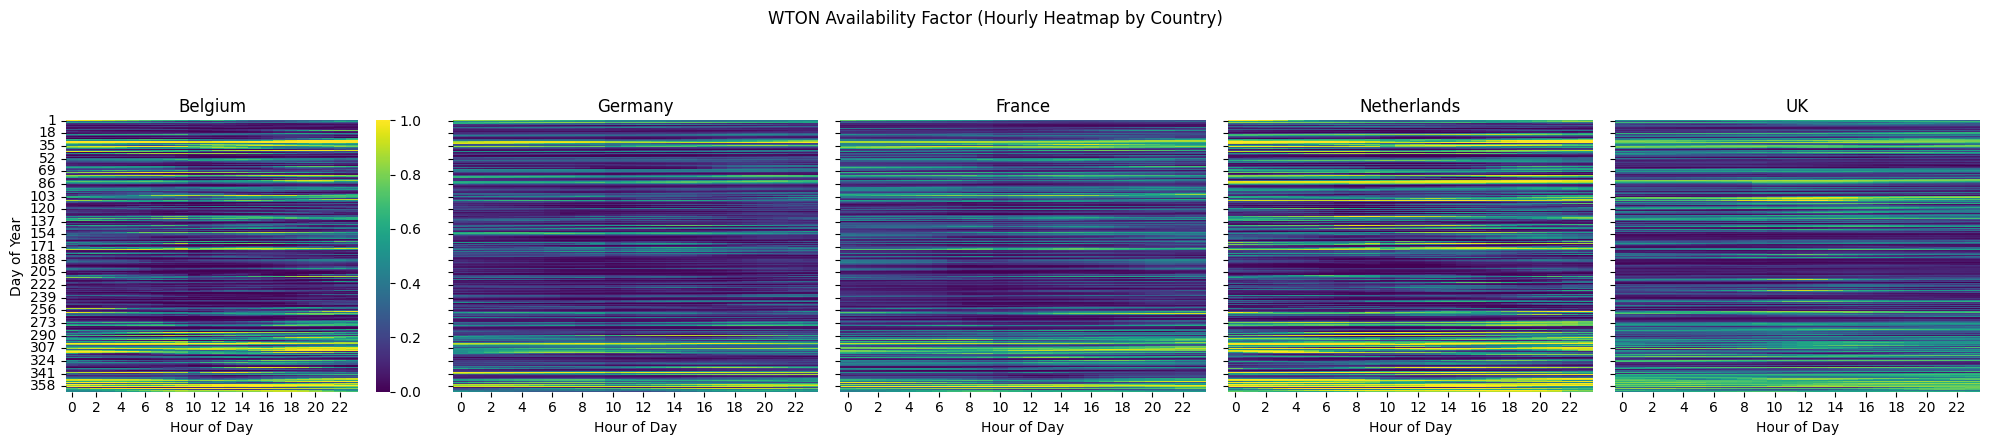

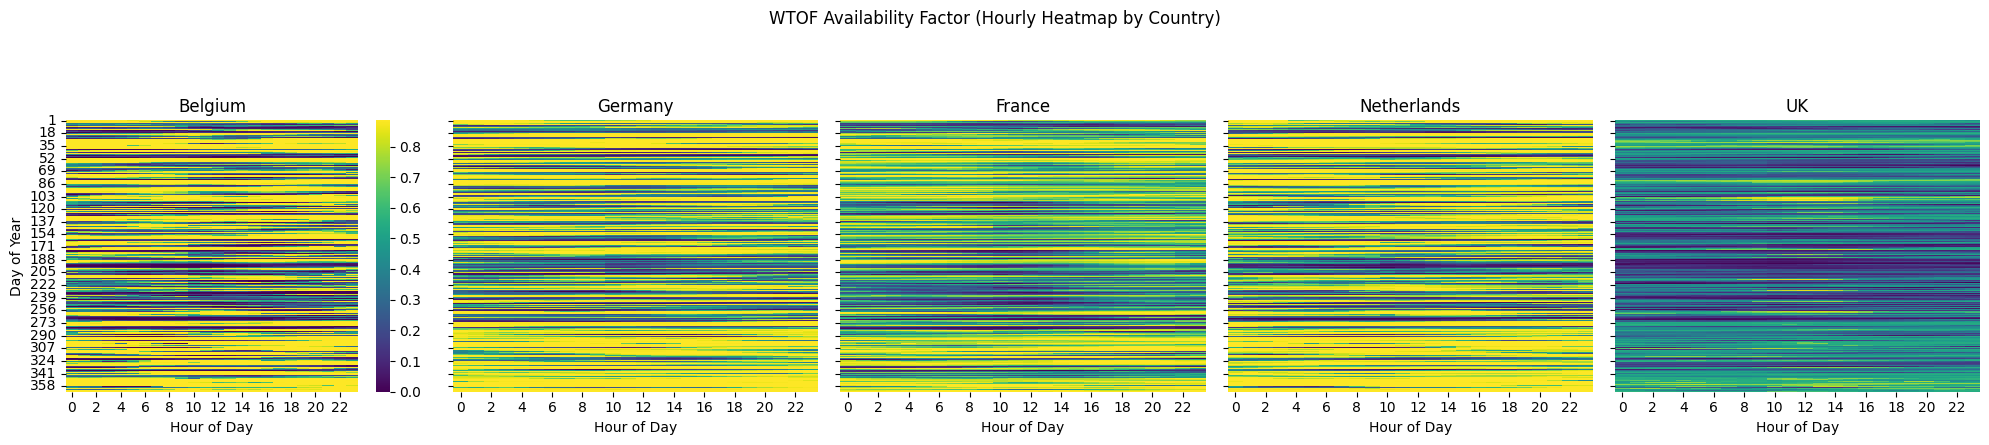

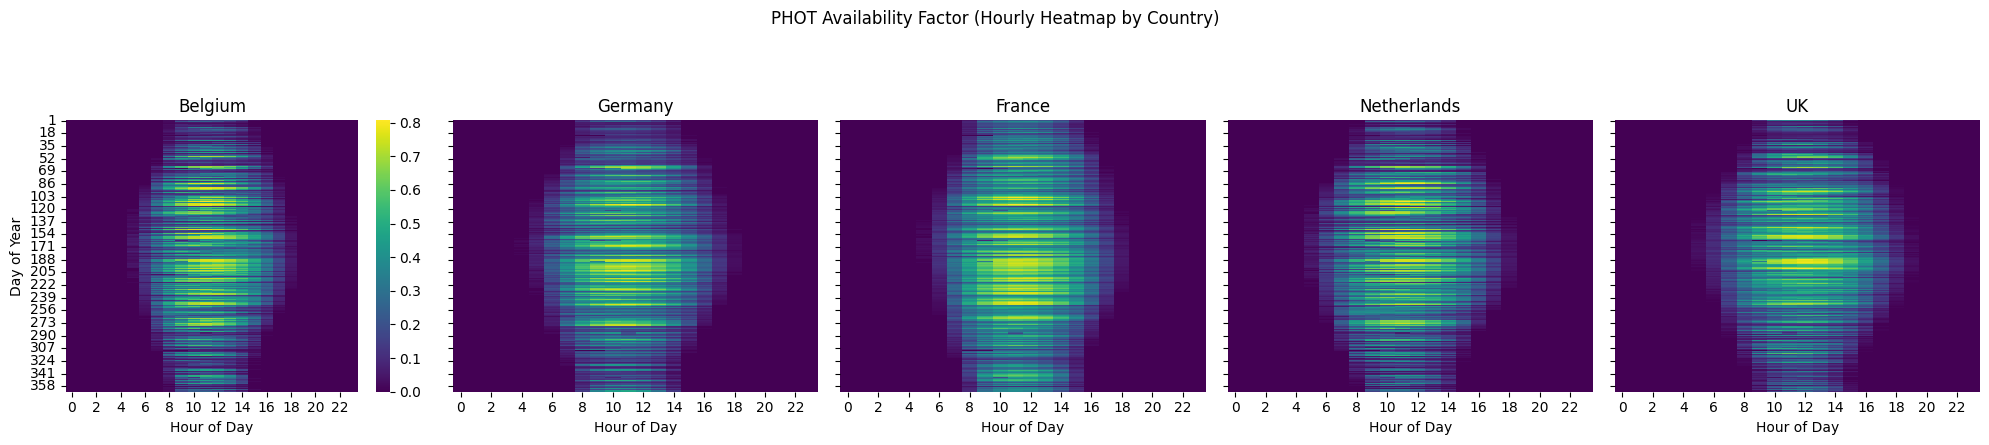

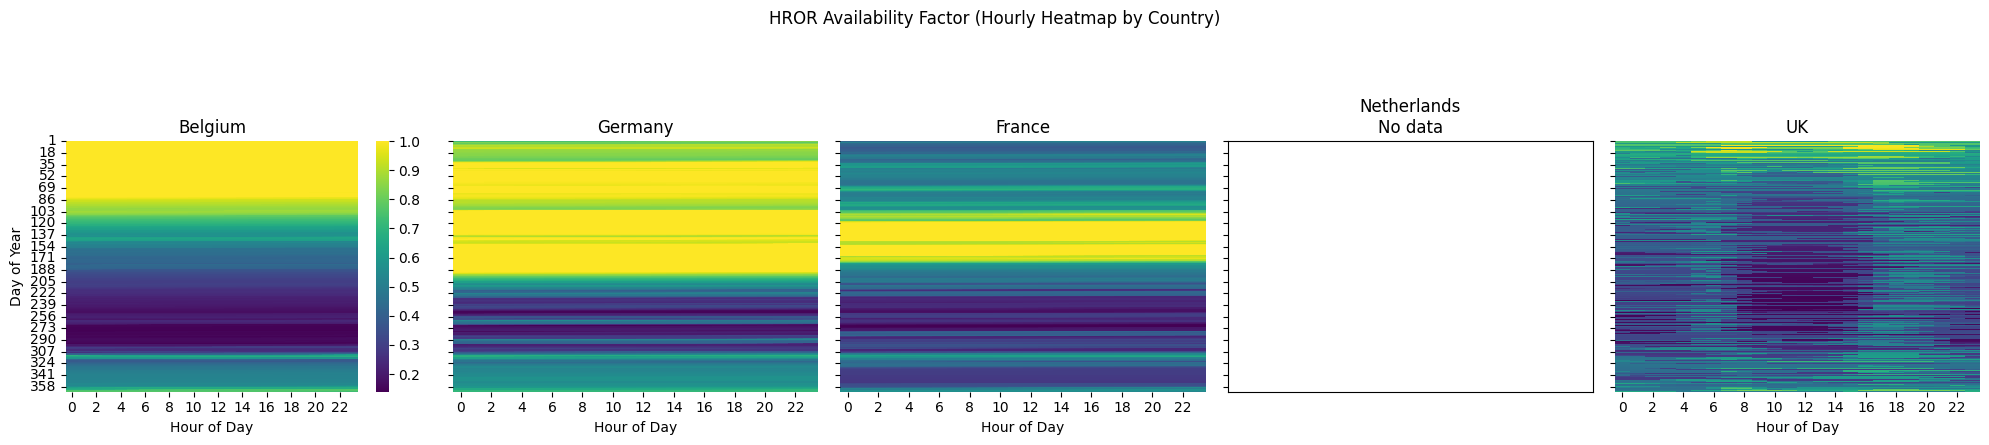

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)
data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Create a heatmap for each resource
for resource in resources:
    fig, axes = plt.subplots(1, len(country_paths), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{resource} Availability Factor (Hourly Heatmap by Country)', y=1.1)

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(values=resource, index='day', columns='hour')

        # Skip if heatmap_data is empty
        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        sns.heatmap(heatmap_data, ax=axes[i], cmap='viridis', cbar=i == 0)
        axes[i].set_title(country)
        axes[i].set_xlabel('Hour of Day')
        axes[i].set_ylabel('Day of Year' if i == 0 else '')

    plt.tight_layout()
    plt.show()


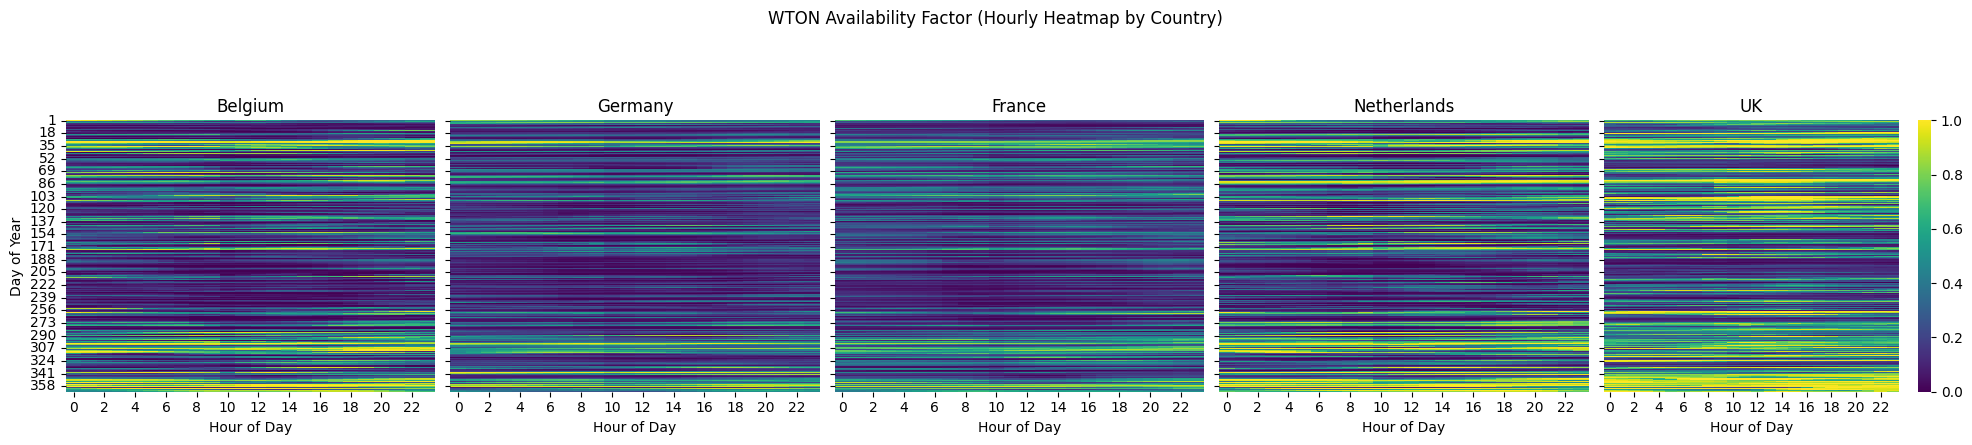

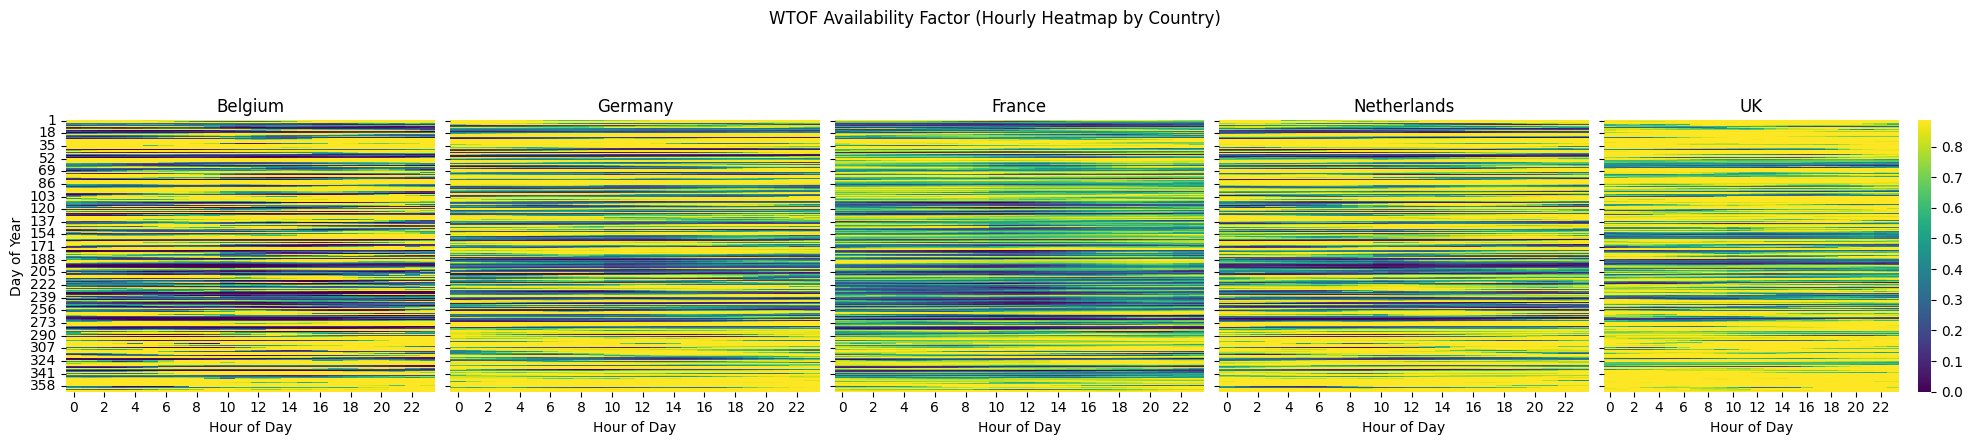

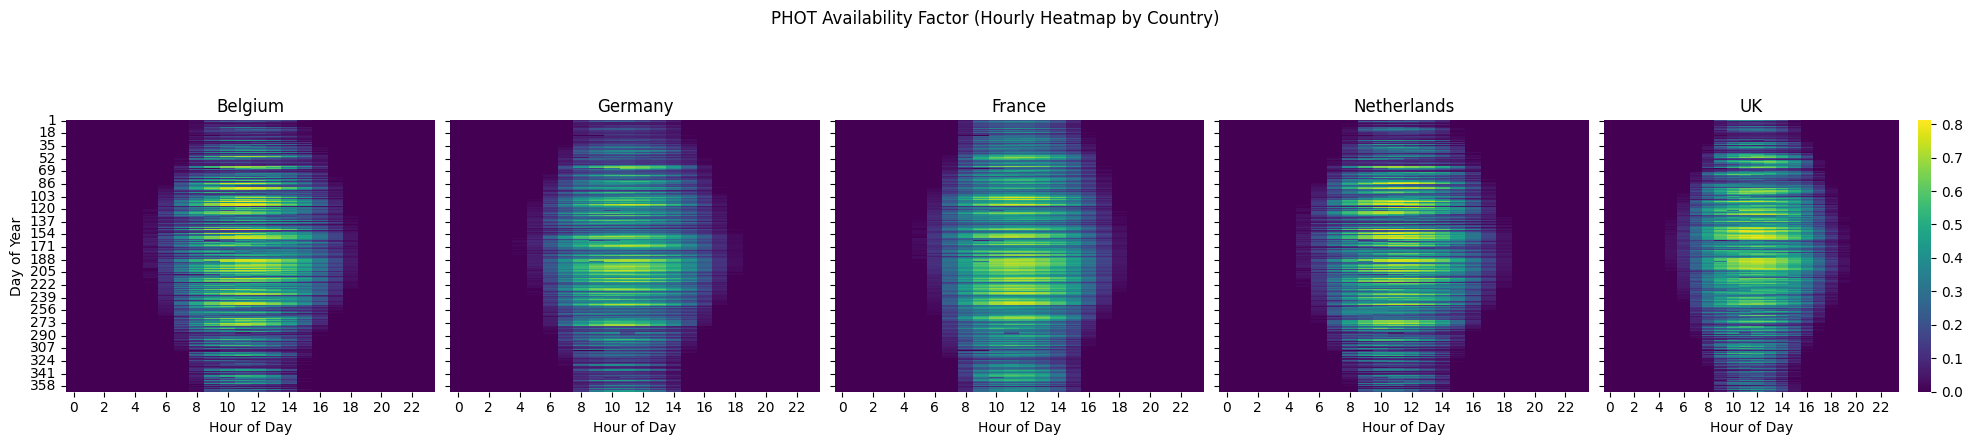

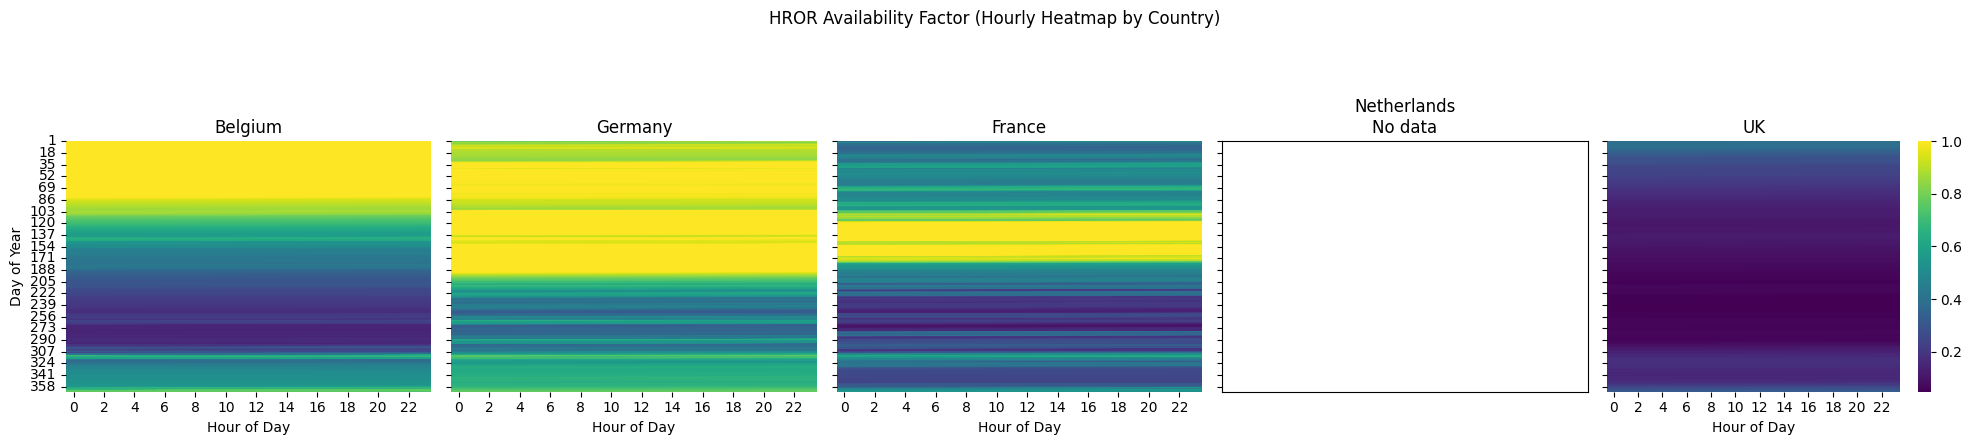

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)
data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Create a heatmap for each resource
for resource in resources:
    # Calculate global min and max for the resource
    vmin = data[resource].min()
    vmax = data[resource].max()

    fig, axes = plt.subplots(1, len(country_paths), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{resource} Availability Factor (Hourly Heatmap by Country)', y=1.1)

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(values=resource, index='day', columns='hour')

        # Skip if heatmap_data is empty
        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        # Use the same vmin and vmax for all heatmaps
        sns.heatmap(heatmap_data, ax=axes[i], cmap='viridis', vmin=vmin, vmax=vmax, cbar=i == len(country_paths) - 1)
        axes[i].set_title(country)
        axes[i].set_xlabel('Hour of Day')
        axes[i].set_ylabel('Day of Year' if i == 0 else '')

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

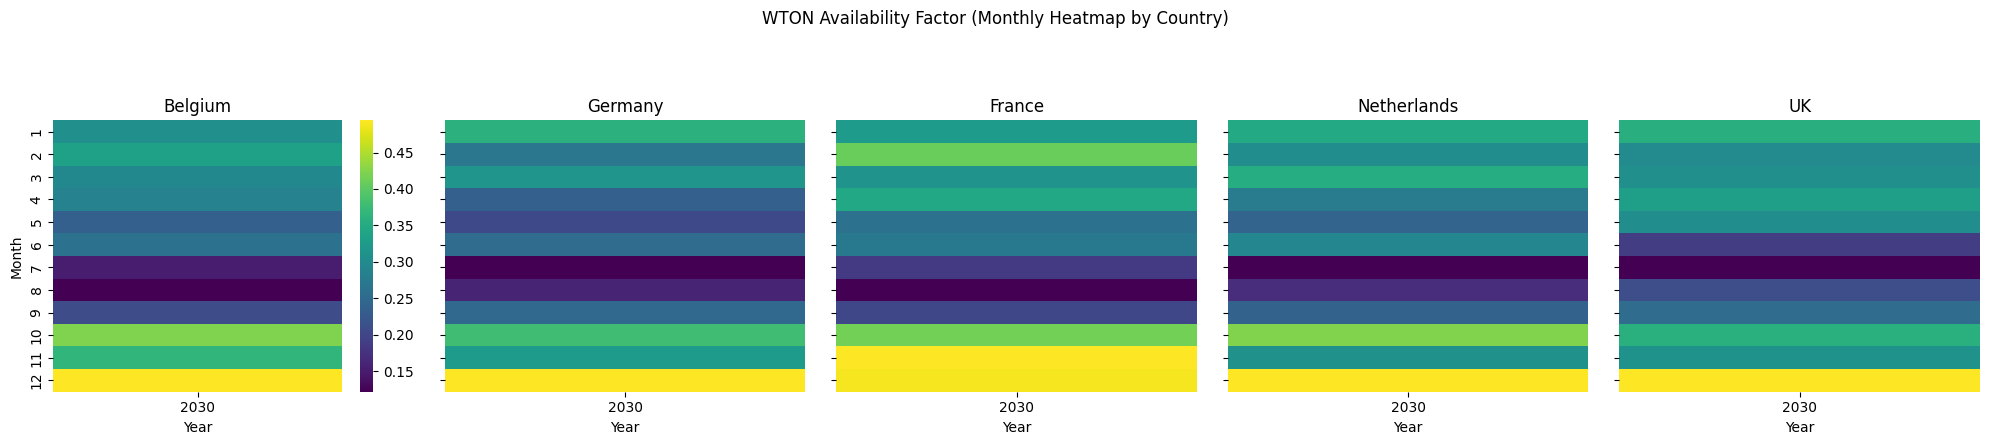

/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

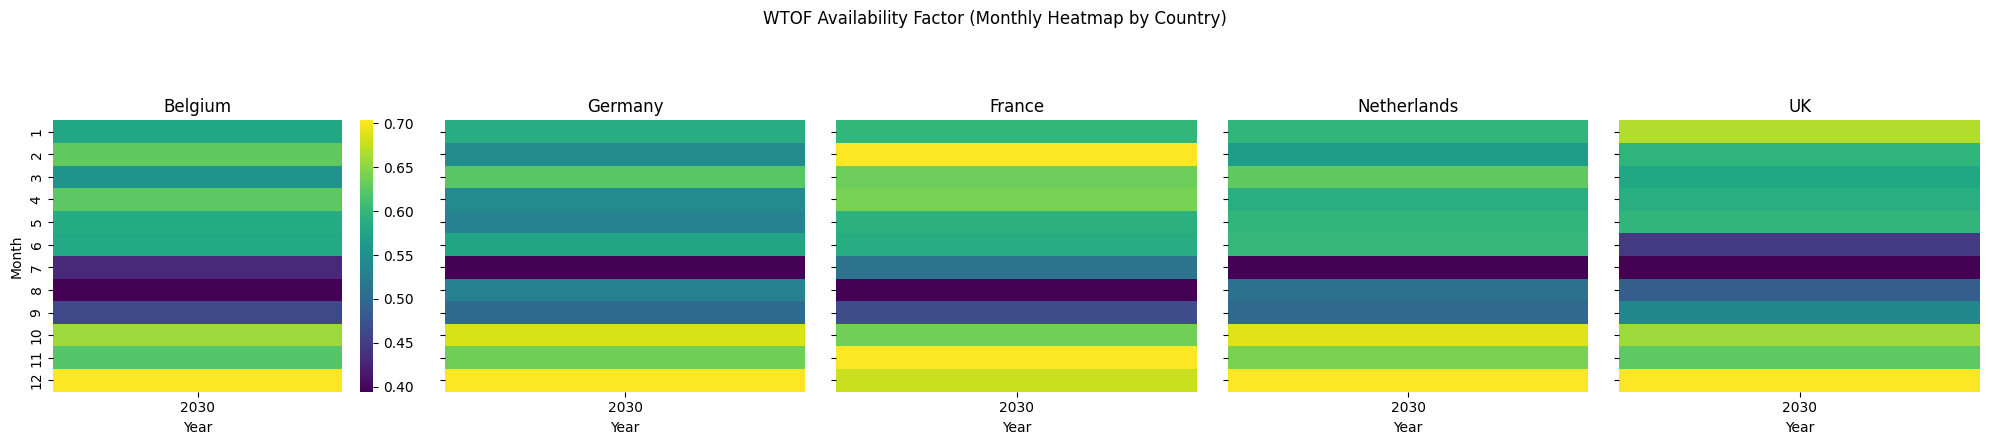

/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

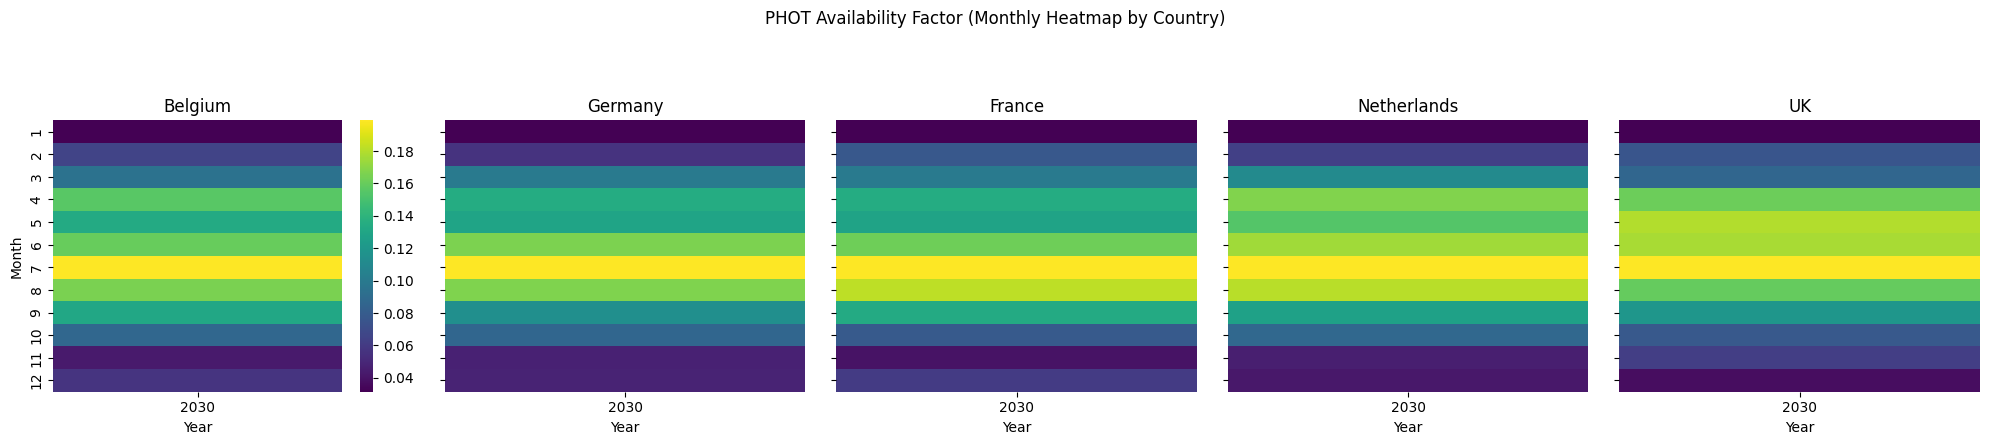

/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample('M').mean(numeric_only=True)
/tmp/ipykernel_255504/196828101.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = country_data.resample

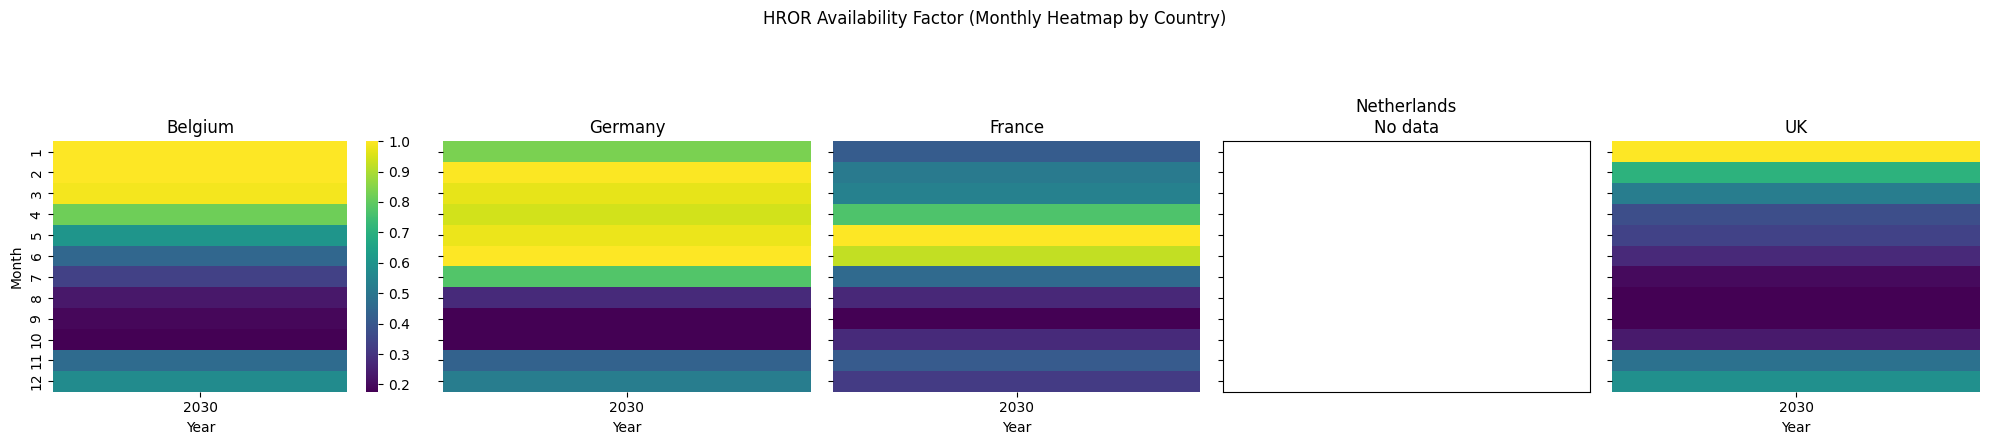

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)
data = pd.concat(all_data)

# Extract month and year
data['month'] = data.index.month
data['year'] = data.index.year

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Create a monthly heatmap for each resource
for resource in resources:
    fig, axes = plt.subplots(1, len(country_paths), figsize=(20, 4), sharey=True)
    fig.suptitle(f'{resource} Availability Factor (Monthly Heatmap by Country)', y=1.1)

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]

        # Aggregate to monthly averages
        monthly_data = country_data.resample('M').mean(numeric_only=True)
        heatmap_data = monthly_data.pivot_table(values=resource, index=monthly_data.index.month, columns=monthly_data.index.year)

        # Skip if heatmap_data is empty
        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data')
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        sns.heatmap(heatmap_data, ax=axes[i], cmap='viridis', cbar=i == 0)
        axes[i].set_title(country)
        axes[i].set_xlabel('Year')
        axes[i].set_ylabel('Month' if i == 0 else '')

    plt.tight_layout()
    plt.show()


In [34]:
import pandas as pd

# --------------------------------------------------
# 1. Input paths
# --------------------------------------------------
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# --------------------------------------------------
# 2. Resource name mapping
# --------------------------------------------------
resource_map = {
    'PHOT': 'Solar',
    'WTON': 'Wind Onshore',
    'WTOF': 'Wind Offshore',
    'HROR': 'Hydro RoR'
}

# --------------------------------------------------
# 3. Helper function to compute averages
# --------------------------------------------------
def compute_availability_stats(df):
    """
    df: DataFrame with datetime index and resource columns
    returns: DataFrame with annual and quarterly averages
    """
    results = []

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Add quarter information
    df['Quarter'] = df.index.quarter

    for col, resource_name in resource_map.items():
        if col not in df.columns:
            continue

        annual_avg = df[col].mean()

        quarterly_avg = (
            df.groupby('Quarter')[col]
            .mean()
            .reindex([1, 2, 3, 4])
        )

        results.append({
            'Resource': resource_name,
            'Annual Avg (%)': annual_avg * 100,
            'Q1 Avg (%)': quarterly_avg.loc[1] * 100,
            'Q2 Avg (%)': quarterly_avg.loc[2] * 100,
            'Q3 Avg (%)': quarterly_avg.loc[3] * 100,
            'Q4 Avg (%)': quarterly_avg.loc[4] * 100,
        })

    return pd.DataFrame(results)


# --------------------------------------------------
# 4. Load data and build final table
# --------------------------------------------------
all_countries_results = []

for country, path in country_paths.items():
    # Load CSV
    df = pd.read_csv(path, index_col=0)

    # Convert index to datetime (important)
    df.index = pd.to_datetime(df.index, utc=True)

    # Compute stats
    stats_df = compute_availability_stats(df)

    # Add country column
    stats_df.insert(0, 'Country', country)

    all_countries_results.append(stats_df)

# --------------------------------------------------
# 5. Final combined table
# --------------------------------------------------
final_table = pd.concat(all_countries_results, ignore_index=True)

# Optional: round for report
final_table = final_table.round(2)

# Display
print(final_table)


        Country       Resource  Annual Avg (%)  Q1 Avg (%)  Q2 Avg (%)  \
0       Belgium          Solar           11.04        6.37       14.94   
1       Belgium   Wind Onshore           28.98       31.15       26.06   
2       Belgium  Wind Offshore           56.78       58.52       59.70   
3       Belgium      Hydro RoR           56.57       99.49       62.42   
4       Germany          Solar           10.85        6.30       14.58   
5       Germany   Wind Onshore           24.19       27.54       19.53   
6       Germany  Wind Offshore           61.54       63.52       58.52   
7       Germany      Hydro RoR           77.18       95.21       98.15   
8        France          Solar           13.29        9.62       16.02   
9        France   Wind Onshore           25.34       27.30       23.59   
10       France  Wind Offshore           56.22       60.74       57.32   
11       France      Hydro RoR           49.97       48.14       88.58   
12  Netherlands          Solar        

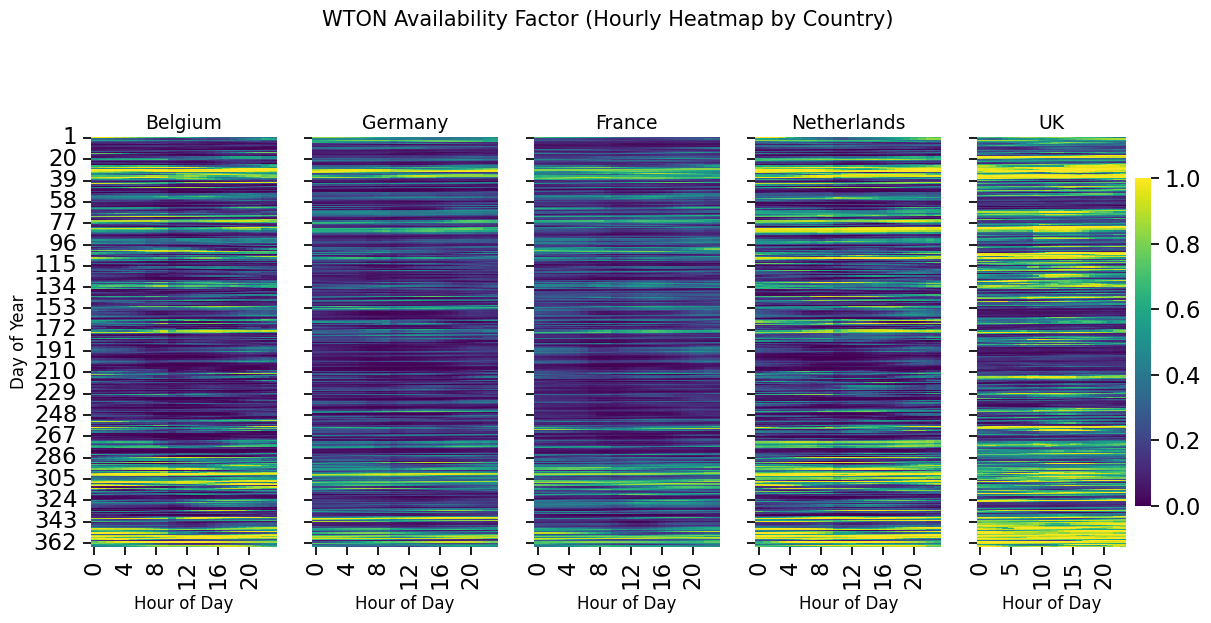

Saved WTON heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/WTON_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

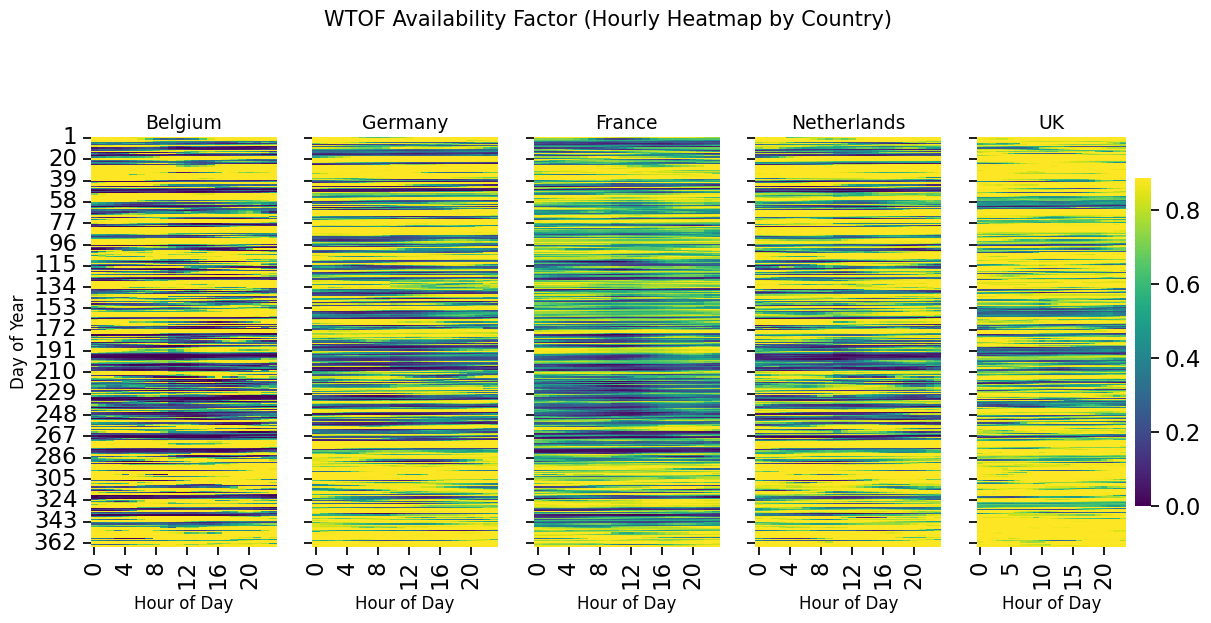

Saved WTOF heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/WTOF_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

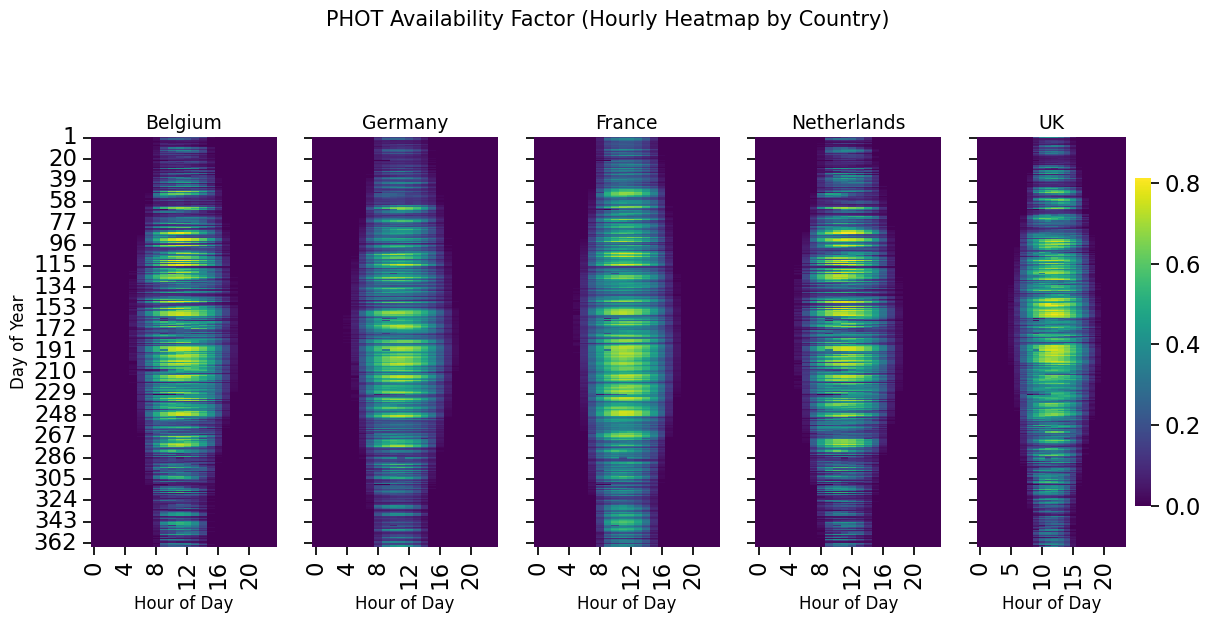

Saved PHOT heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/PHOT_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

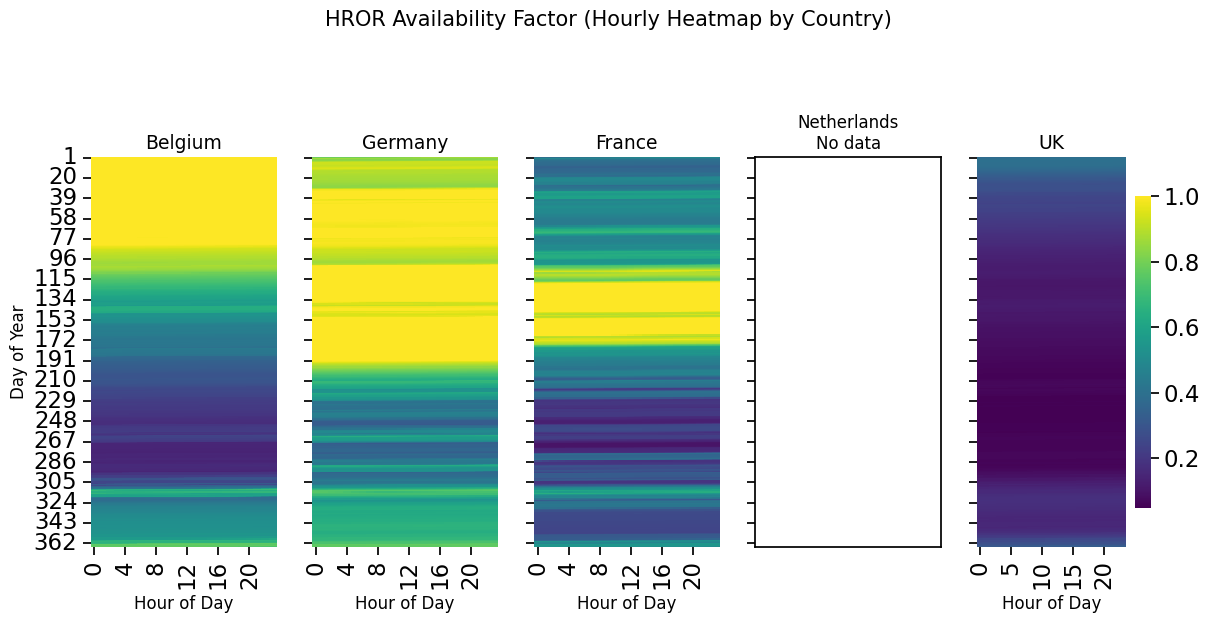

Saved HROR heatmap to: /home/ray/Downloads/Downloads/heatmaps_individual/HROR_availability_heatmap.pdf


<Figure size 640x480 with 0 Axes>

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)

data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Output folder for individual plots
output_folder = '/home/ray/Downloads/Downloads/heatmaps_individual'
os.makedirs(output_folder, exist_ok=True)

# Scaling factor for font
font_scale = 1.5
sns.set_context("notebook", font_scale=font_scale)

# Create a separate plot for each resource
for resource in resources:
    # Calculate global min and max for the resource
    vmin = data[resource].min()
    vmax = data[resource].max()

    # Adjust figure size: taller and narrower
    fig, axes = plt.subplots(
        1, len(country_paths),
        figsize=(len(country_paths) * 2.5, 6),  # width per country = 2.5, height = 6
        sharey=True
    )
    fig.suptitle(
        f'{resource} Availability Factor (Hourly Heatmap by Country)',
        y=1.05,
        fontsize=font_scale*10  # scale title font
    )

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(
            values=resource,
            index='day',
            columns='hour'
        )

        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data', fontsize=font_scale*8)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        sns.heatmap(
            heatmap_data,
            ax=axes[i],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            cbar=i == len(country_paths) - 1,
            cbar_kws={'shrink': 0.8}  # shrink colorbar a bit
        )

        axes[i].set_title(country, fontsize=font_scale*9)
        axes[i].set_xlabel('Hour of Day', fontsize=font_scale*8)
        axes[i].set_ylabel('Day of Year' if i == 0 else '', fontsize=font_scale*8)

    plt.tight_layout()
    plt.show()

    # Save each resource heatmap separately
    file_path = os.path.join(output_folder, f'{resource}_availability_heatmap.pdf')
    plt.savefig(file_path, format='pdf', bbox_inches='tight')
    plt.close(fig)

    print(f"Saved {resource} heatmap to: {file_path}")


Saved: /home/ray/Downloads/Downloads/WTON_heatmap.pdf


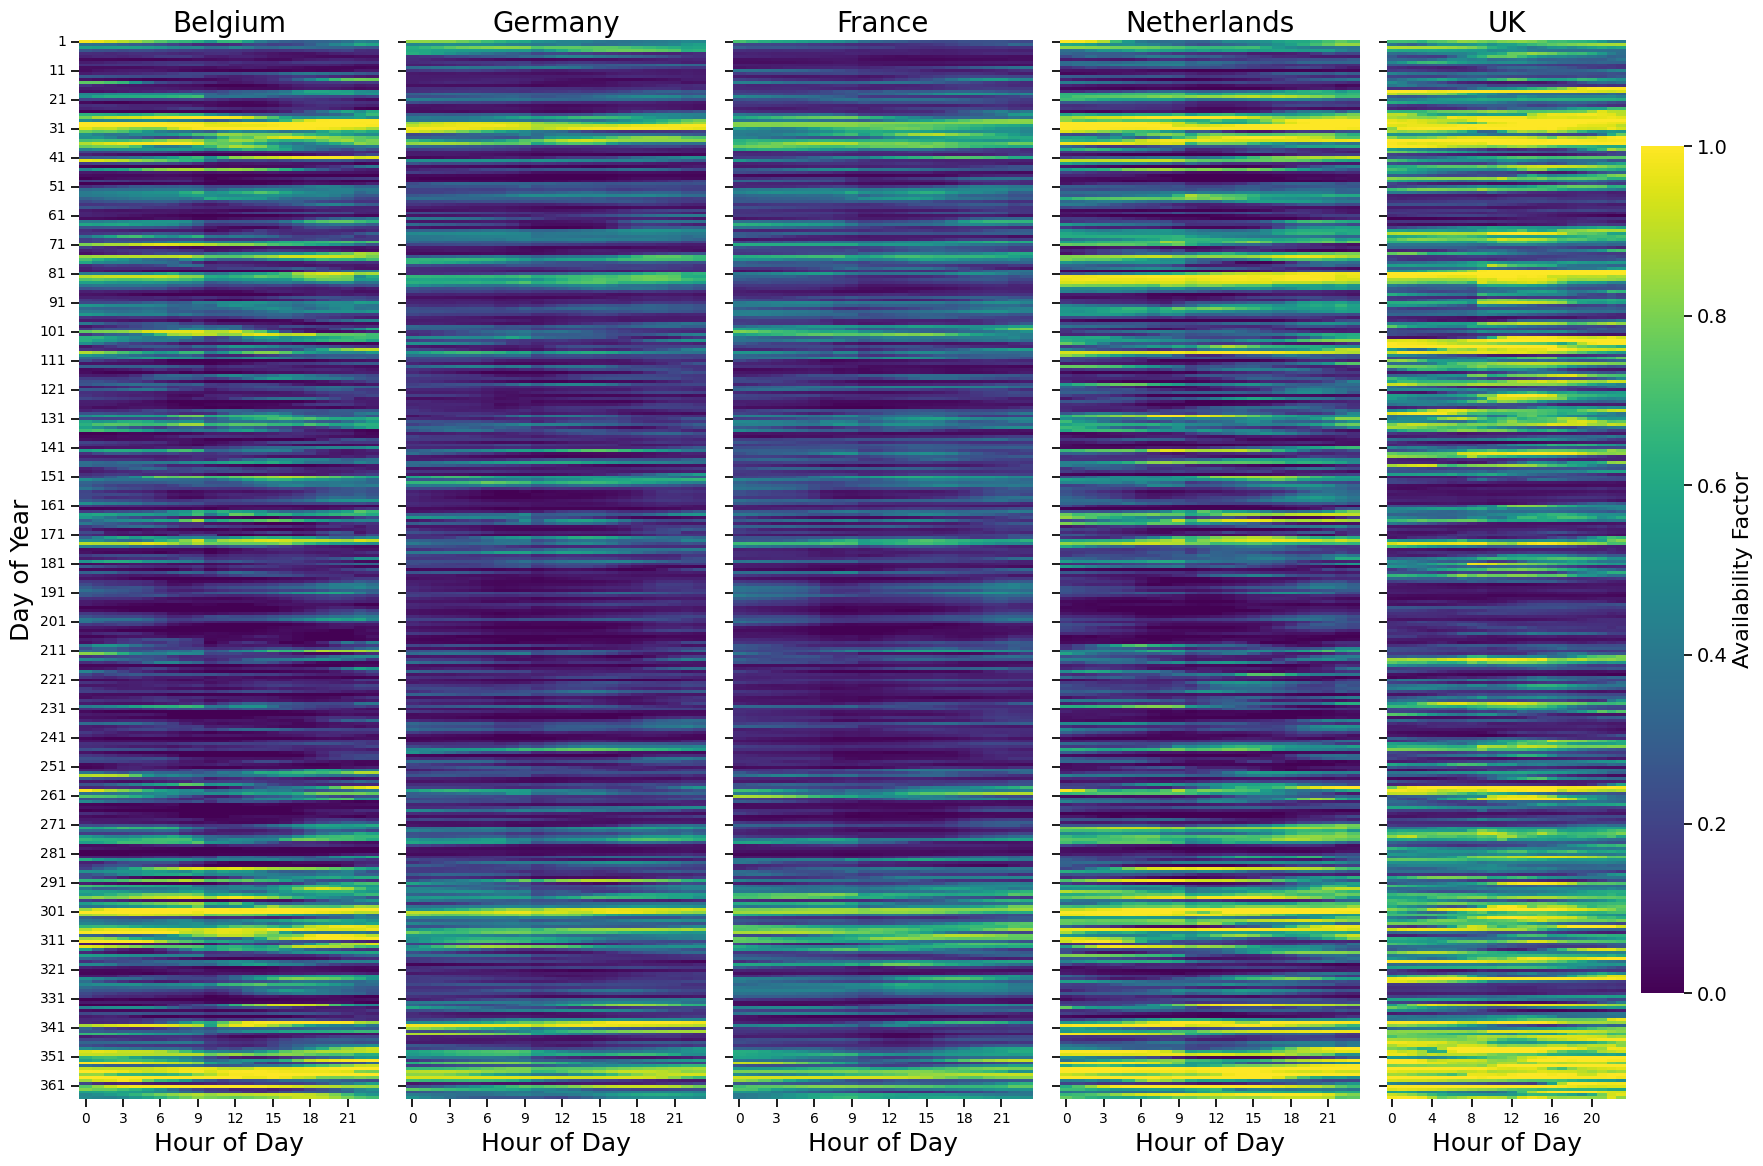

Saved: /home/ray/Downloads/Downloads/WTOF_heatmap.pdf


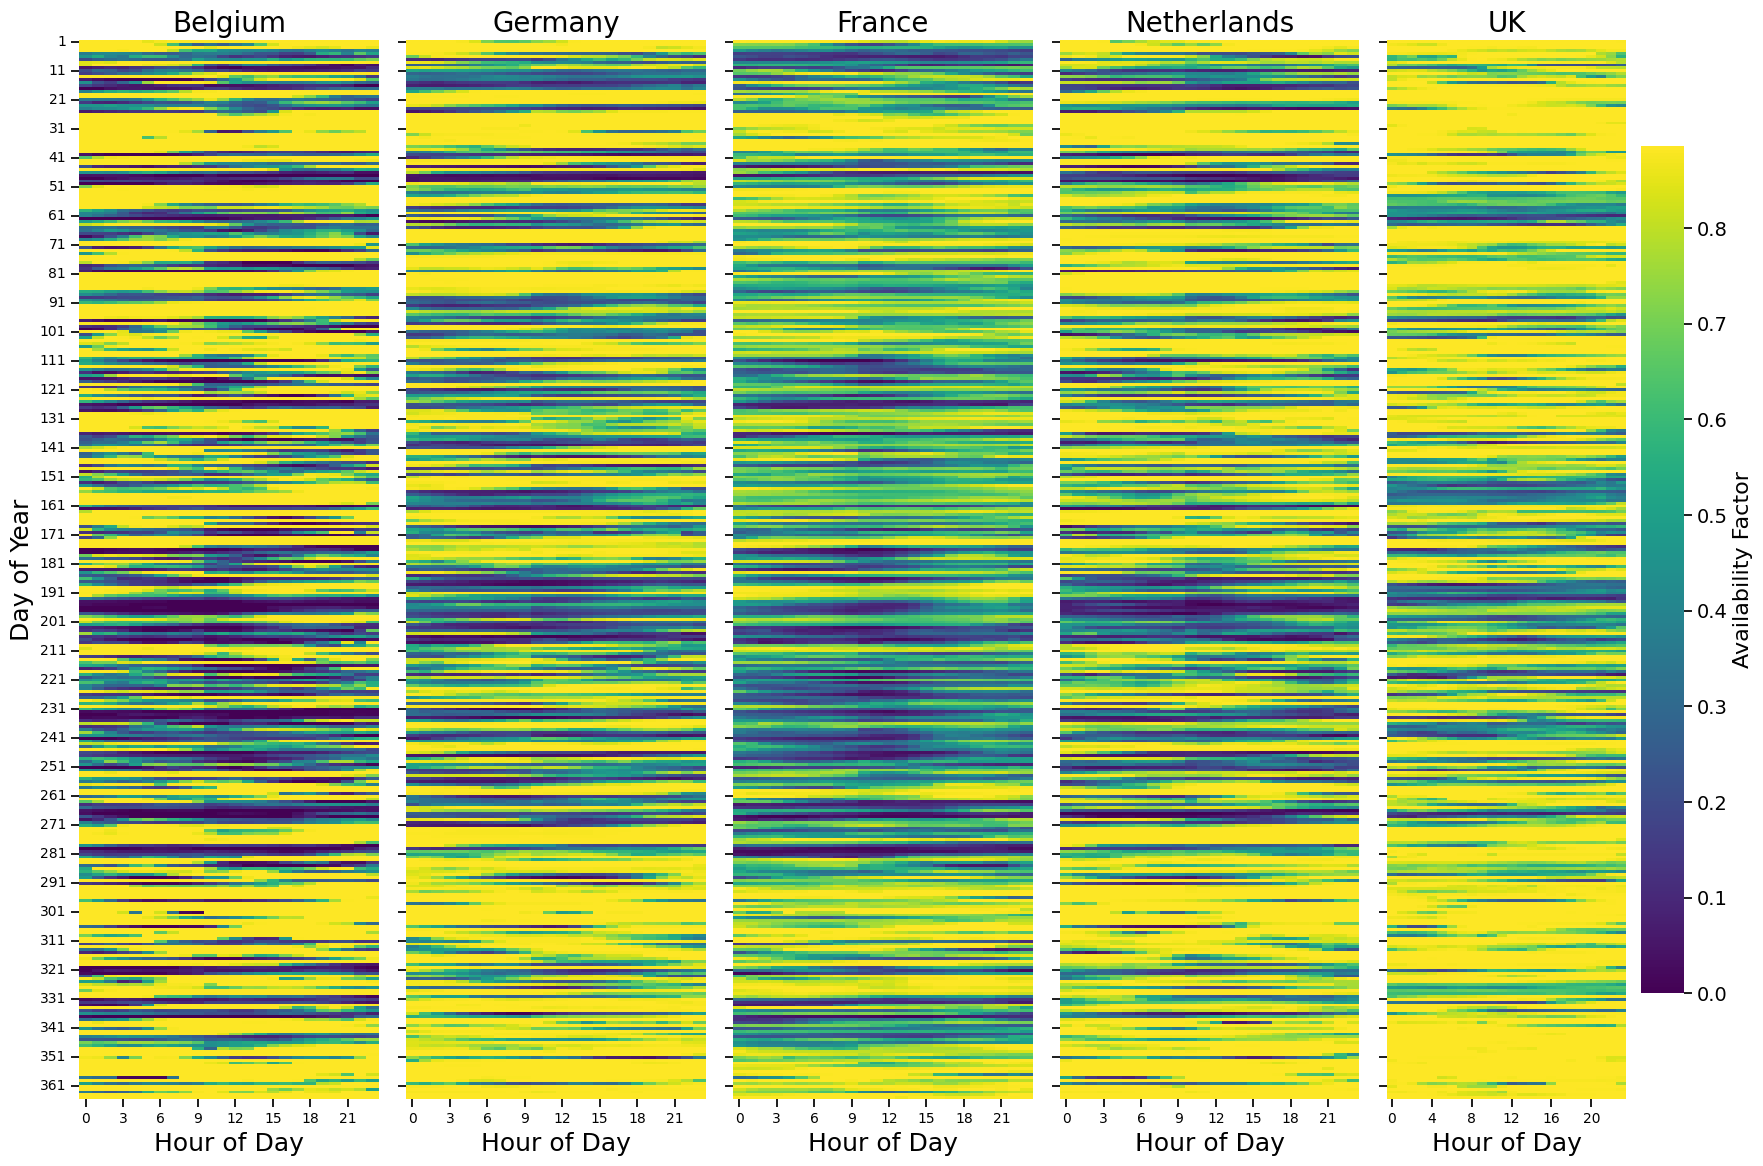

Saved: /home/ray/Downloads/Downloads/PHOT_heatmap.pdf


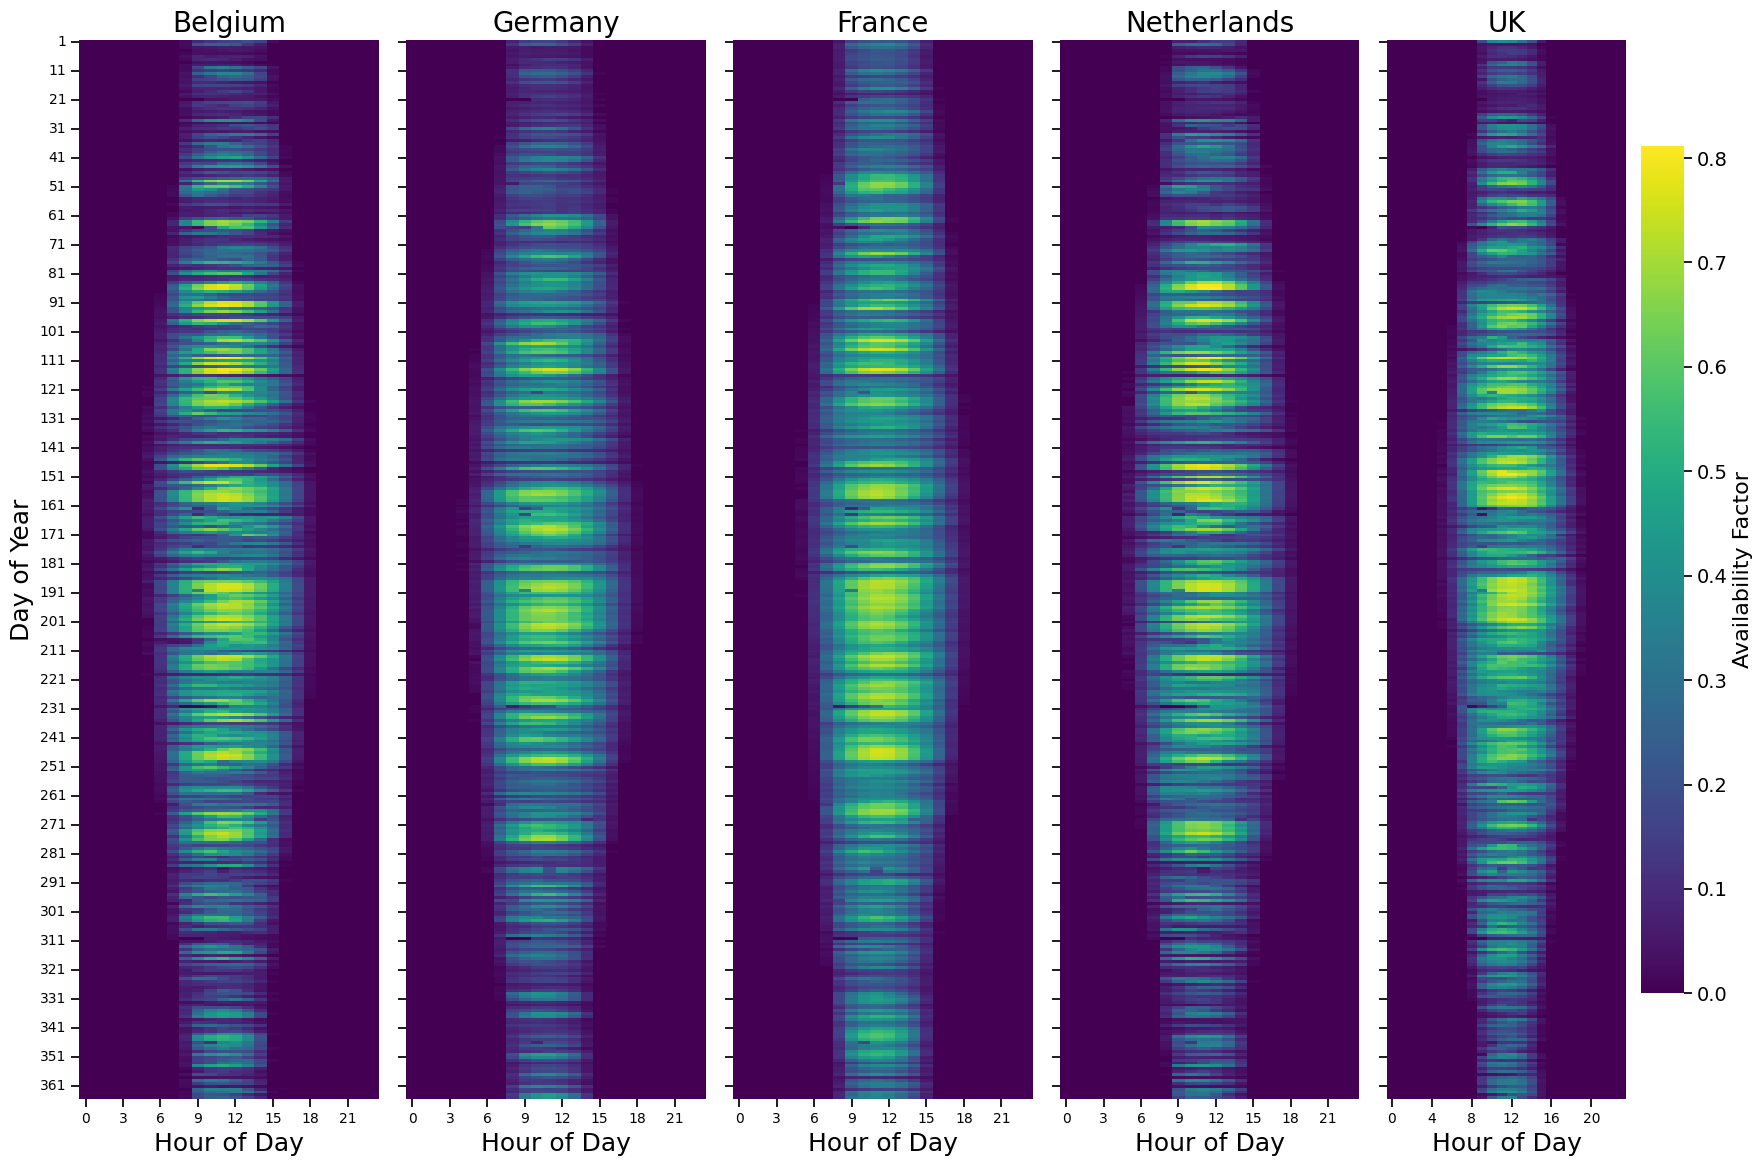

Saved: /home/ray/Downloads/Downloads/HROR_heatmap.pdf


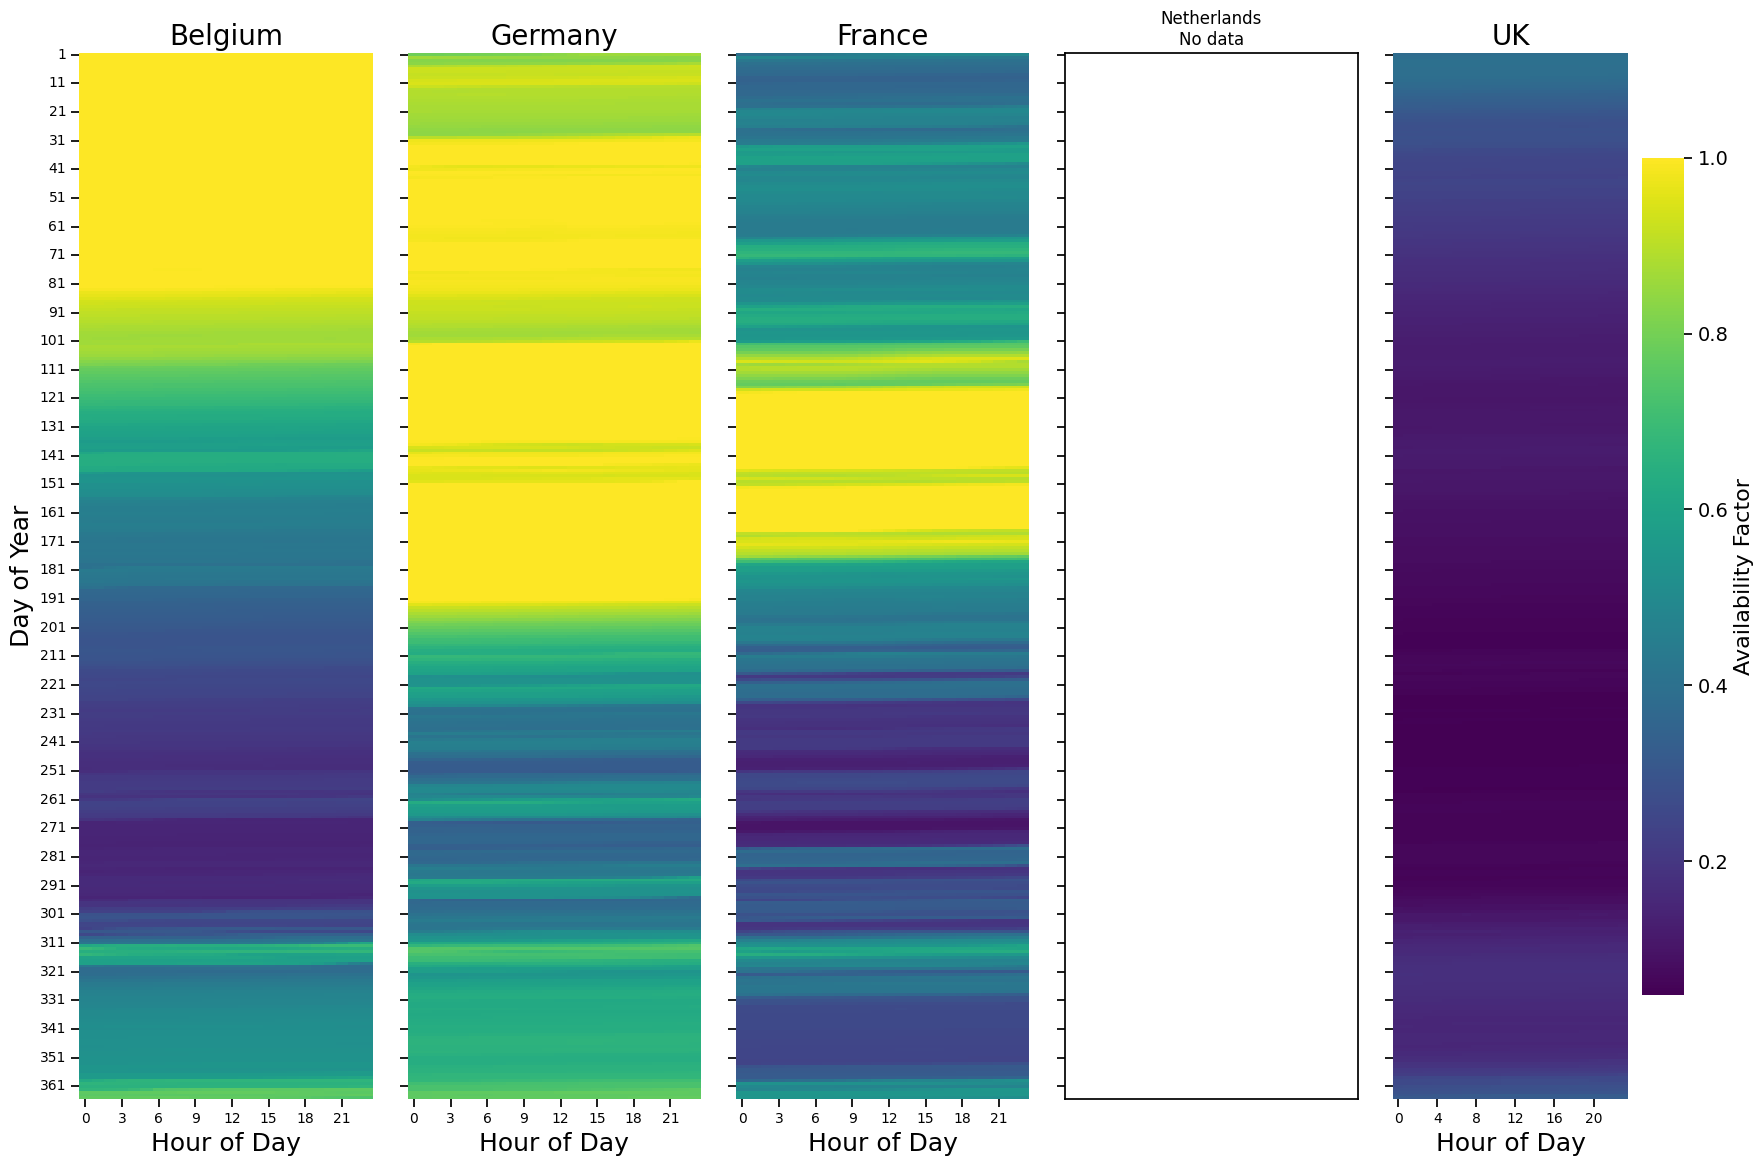

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Replace this with the actual paths to your CSV files for each country
country_paths = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/BE/1h/2030.csv',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/DE/1h/2030.csv',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/FR/1h/2030.csv',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/NL/1h/2030.csv',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/AvailabilityFactors/UK/1h/2030.csv',
}

# Load and concatenate all data
all_data = []
for country, path in country_paths.items():
    df = pd.read_csv(path, parse_dates=[0], index_col=0)
    df['country'] = country
    all_data.append(df)

data = pd.concat(all_data)

# Extract hour and day
data['hour'] = data.index.hour
data['day'] = data.index.dayofyear

# Resources to plot
resources = ['WTON', 'WTOF', 'PHOT', 'HROR']

# Output folder
output_folder = '/home/ray/Downloads/Downloads/'

# Loop through each resource
for resource in resources:
    # Calculate global min and max for consistent color scaling
    vmin = data[resource].min()
    vmax = data[resource].max()

    # Create figure with taller and narrower heatmaps
    fig, axes = plt.subplots(
        1, len(country_paths),
        figsize=(18, 12),  # narrower and taller
        sharey=True
    )
#    fig.suptitle(
#        f'{resource} Availability Factor (Hourly Heatmap by Country)',
#        y=1.05,
#        fontsize=16
#    )

    for i, (country, _) in enumerate(country_paths.items()):
        country_data = data[data['country'] == country]
        heatmap_data = country_data.pivot_table(
            values=resource,
            index='day',
            columns='hour'
        )

        if heatmap_data.empty or heatmap_data.isna().all().all():
            axes[i].set_title(f'{country}\nNo data', fontsize=12)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
            continue

        # Draw heatmap with increased legend size
        cbar_kws = {"label": "Availability Factor", "shrink": 0.8, "orientation": "vertical"}
        sns.heatmap(
            heatmap_data,
            ax=axes[i],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            cbar=i == len(country_paths) - 1,
            cbar_kws=cbar_kws
        )

        # Increase colorbar label font size
        if i == len(country_paths) - 1:
            axes[i].collections[0].colorbar.ax.tick_params(labelsize=14)  # scale by ~1.5
            axes[i].collections[0].colorbar.ax.yaxis.label.set_size(16)

        axes[i].set_title(country, fontsize=20)
        axes[i].set_xlabel('Hour of Day', fontsize=18)
        axes[i].set_ylabel('Day of Year' if i == 0 else '', fontsize=18)


        # Reduce the size of the numbers on the X and Y axes
        axes[i].tick_params(axis='x', labelsize=10)  # Adjust the labelsize for X-axis
        axes[i].tick_params(axis='y', labelsize=10)  # Adjust the labelsize for Y-axis

    plt.tight_layout()

    # Save each figure as PDF FIRST
    pdf_file = f"{output_folder}{resource}_heatmap.pdf"
    plt.savefig(pdf_file, bbox_inches='tight', dpi=300)  # Added dpi for higher quality if needed
    print(f"Saved: {pdf_file}")

    # THEN display it
    plt.show()

    # Finally, close the figure
    plt.close(fig)

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Belgium_HPHS_2030_2040_2050.pdf


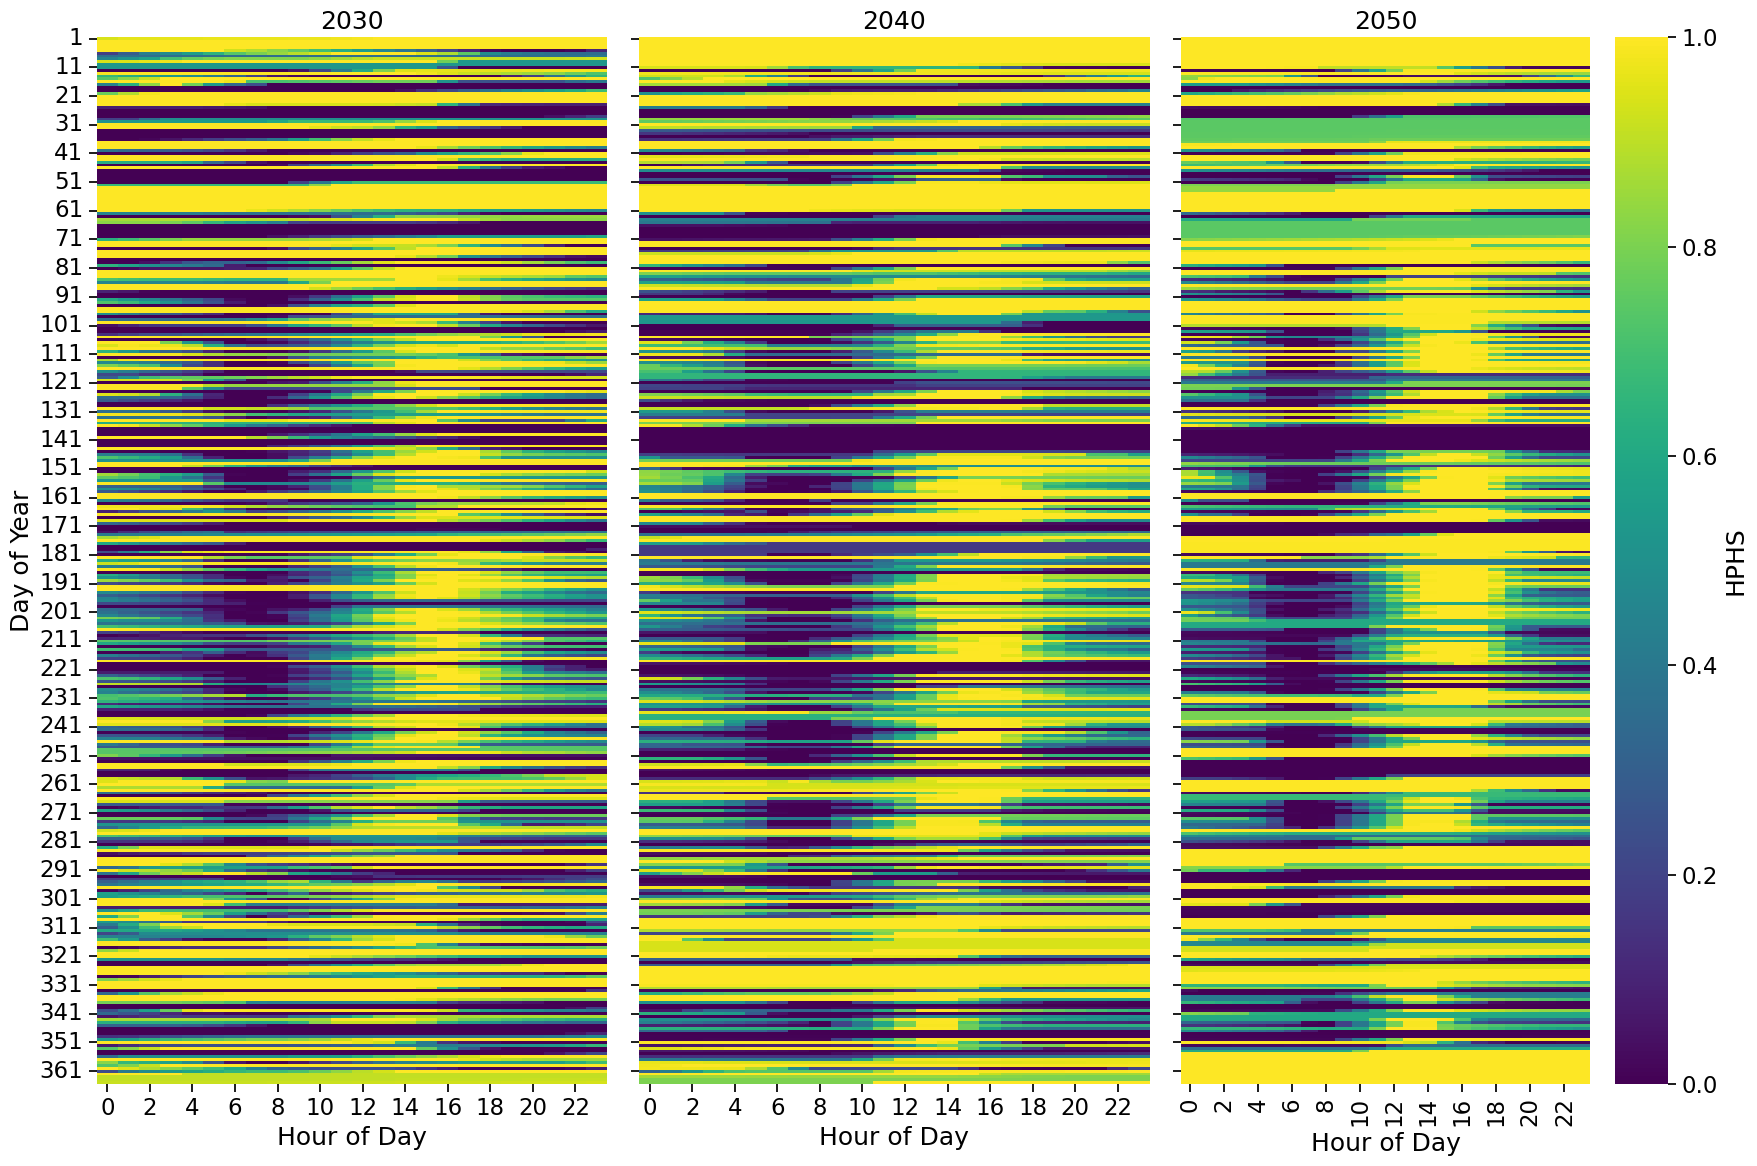

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Belgium_HDAM_2030_2040_2050.pdf


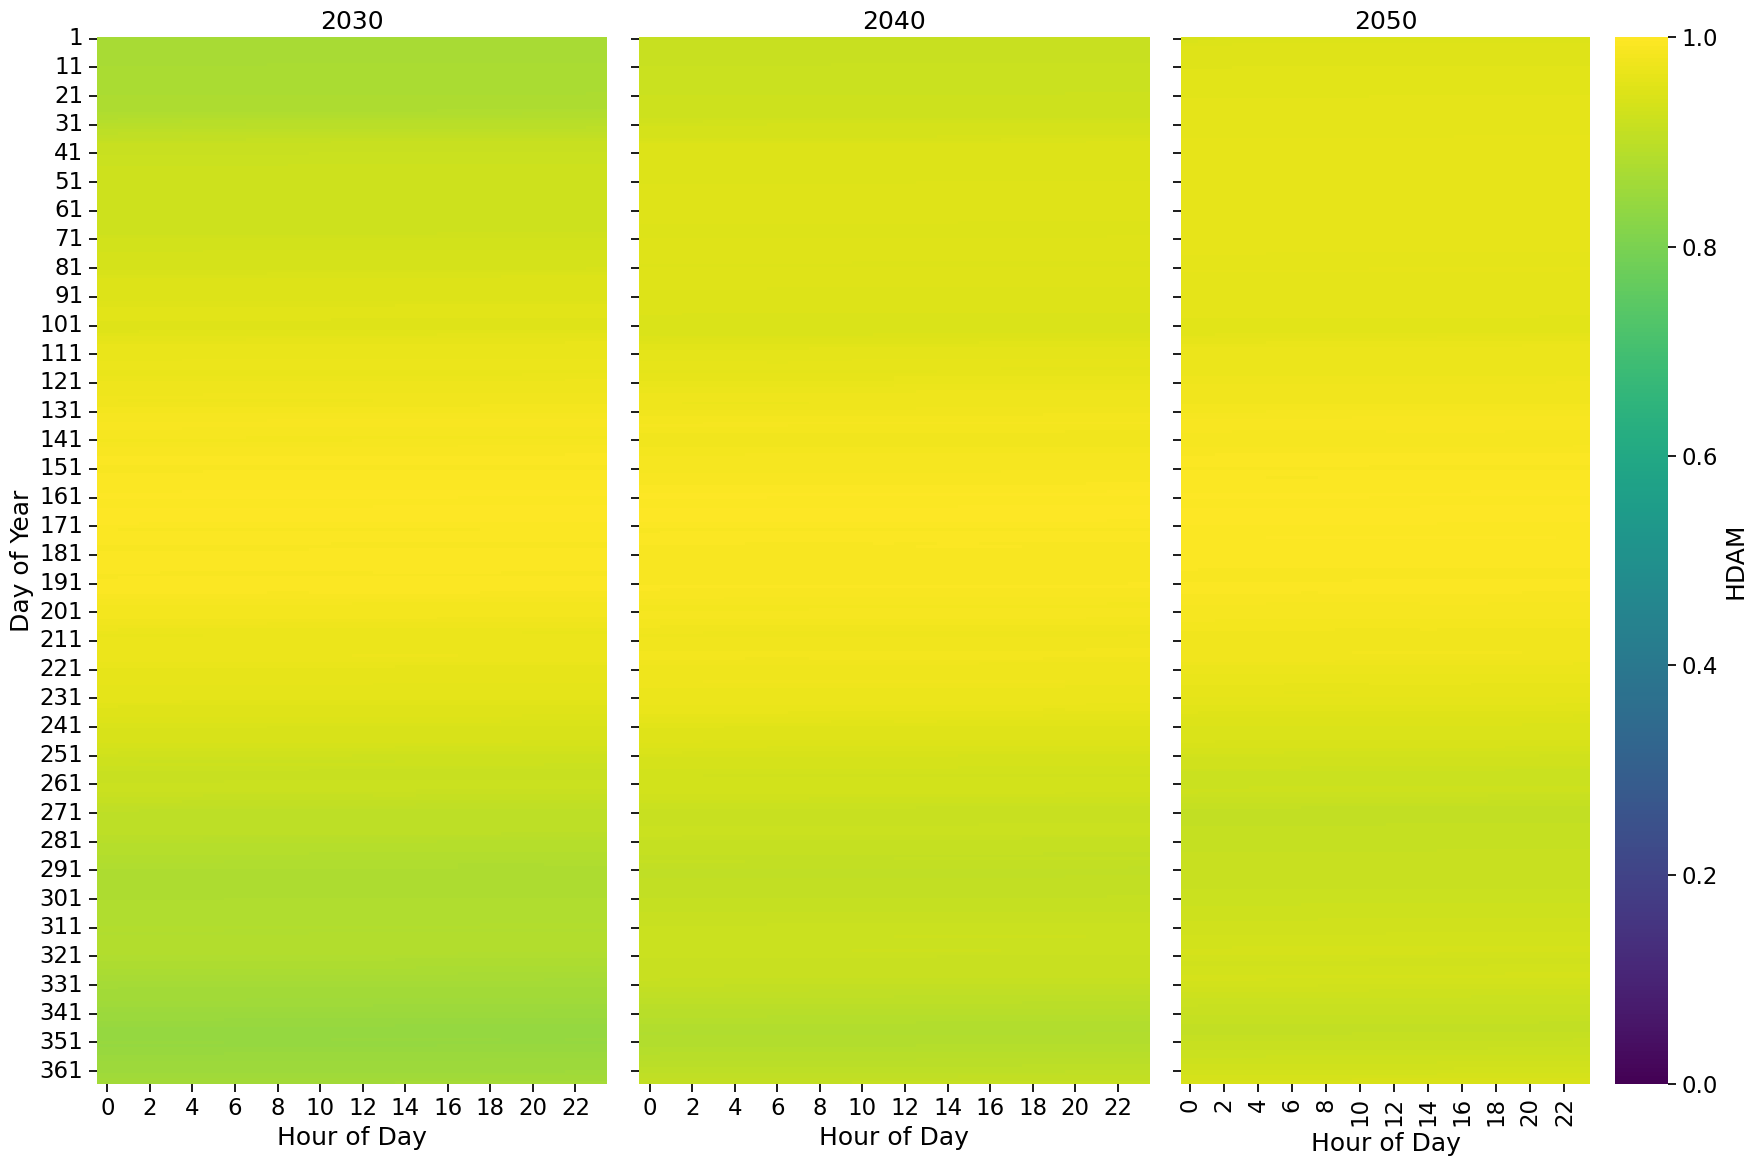

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Germany_HPHS_2030_2040_2050.pdf


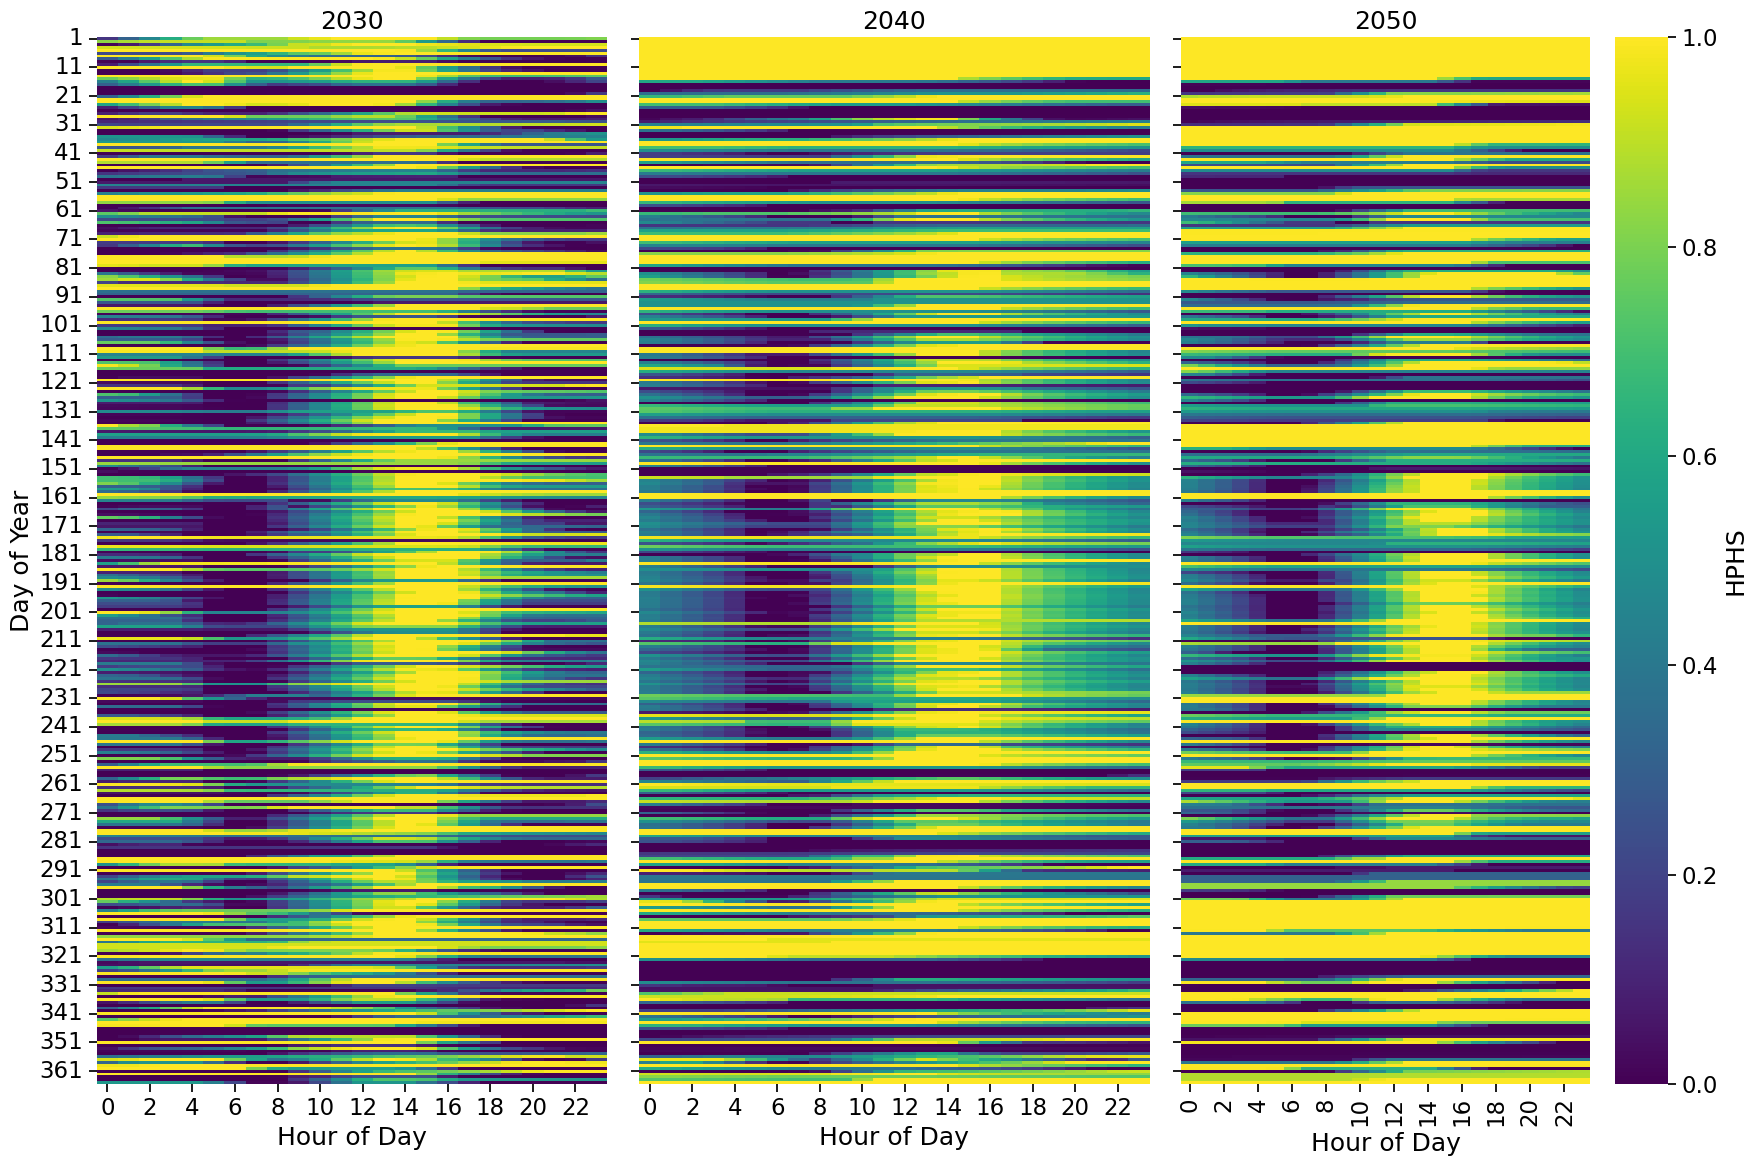

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Germany_HDAM_2030_2040_2050.pdf


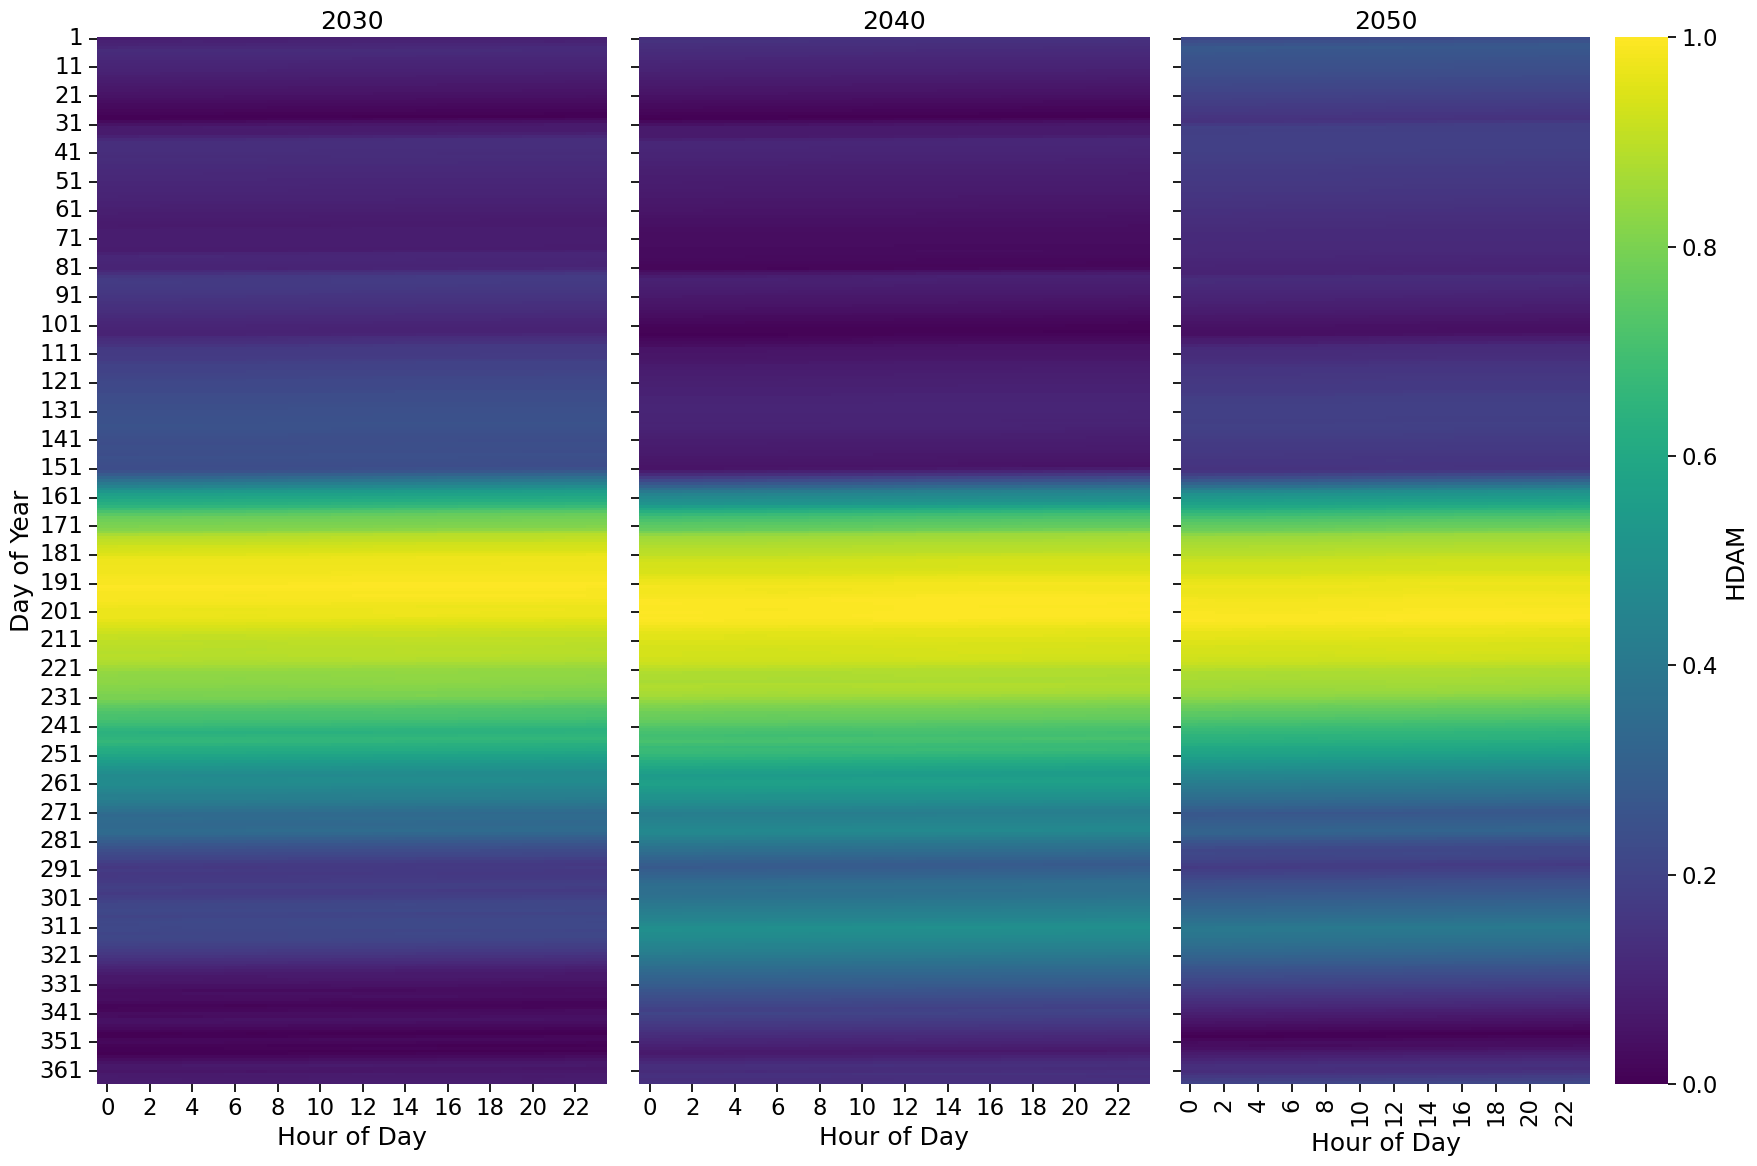

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/France_HPHS_2030_2040_2050.pdf


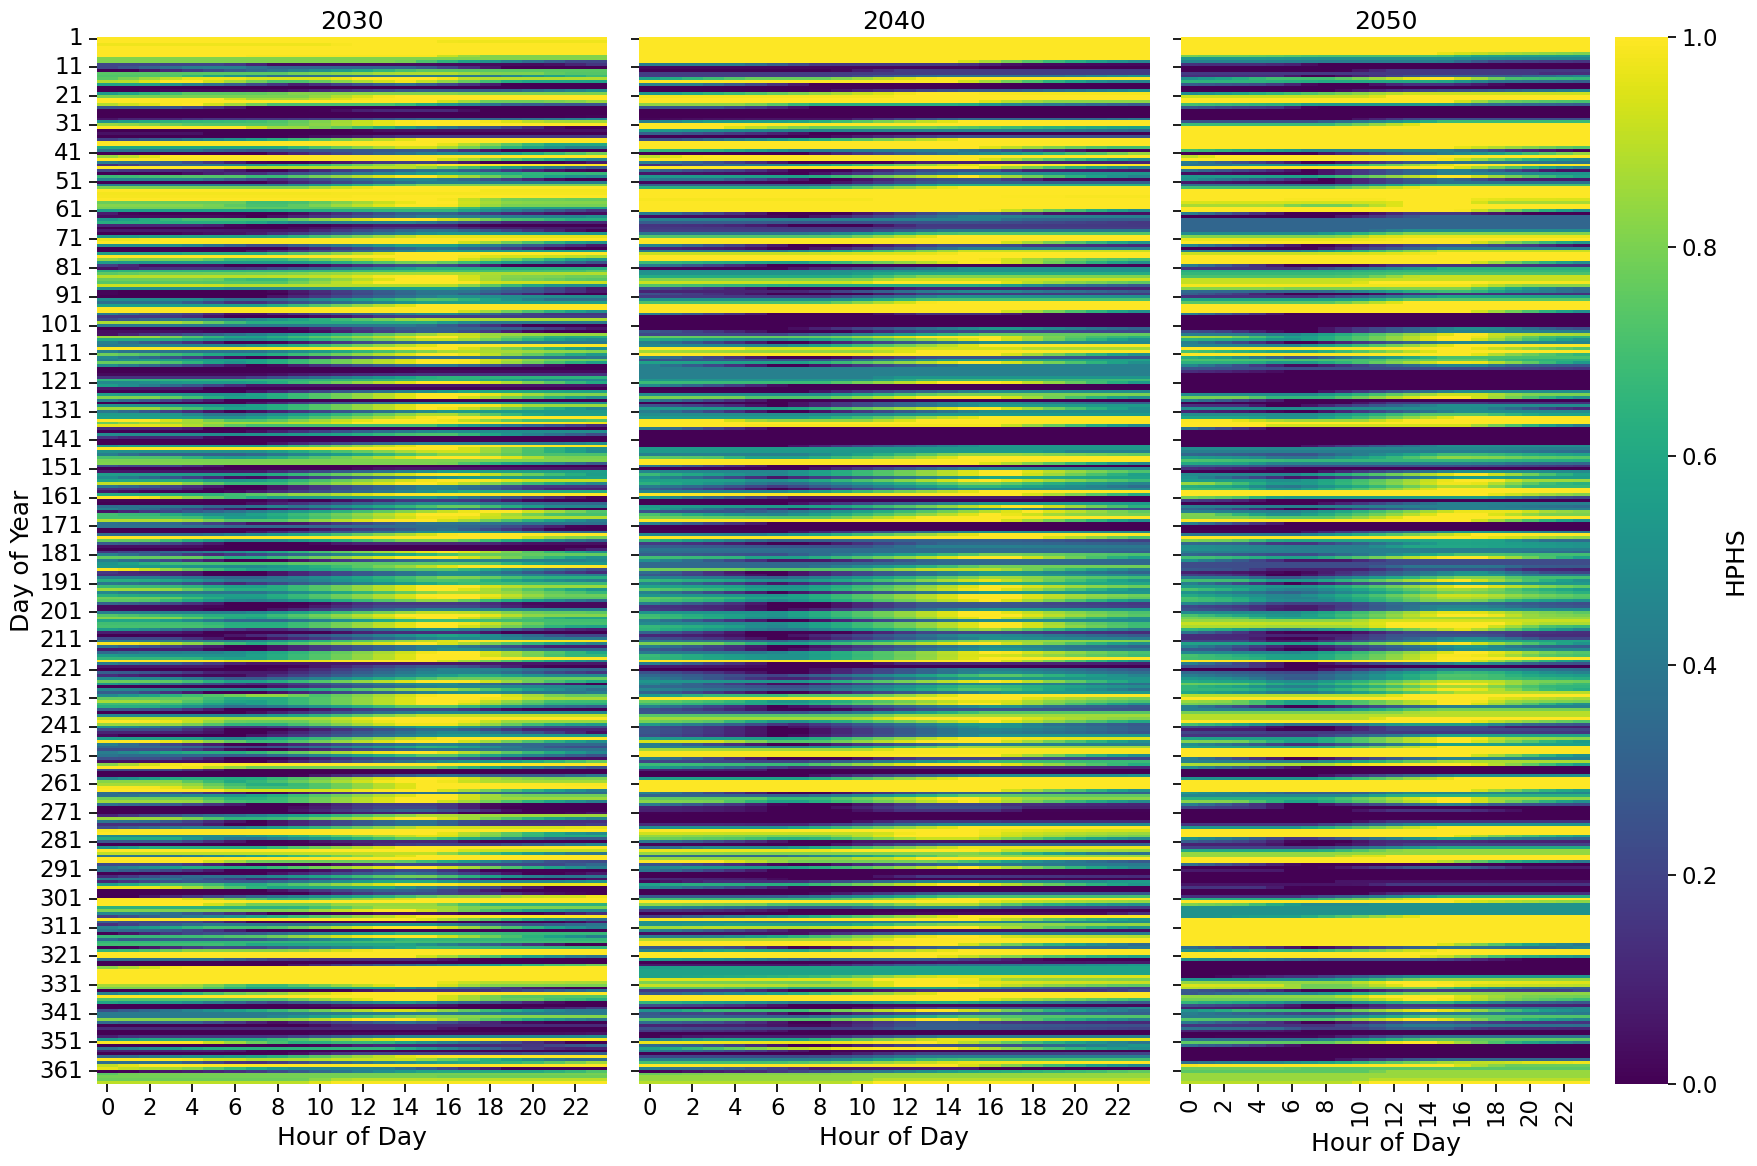

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/France_HDAM_2030_2040_2050.pdf


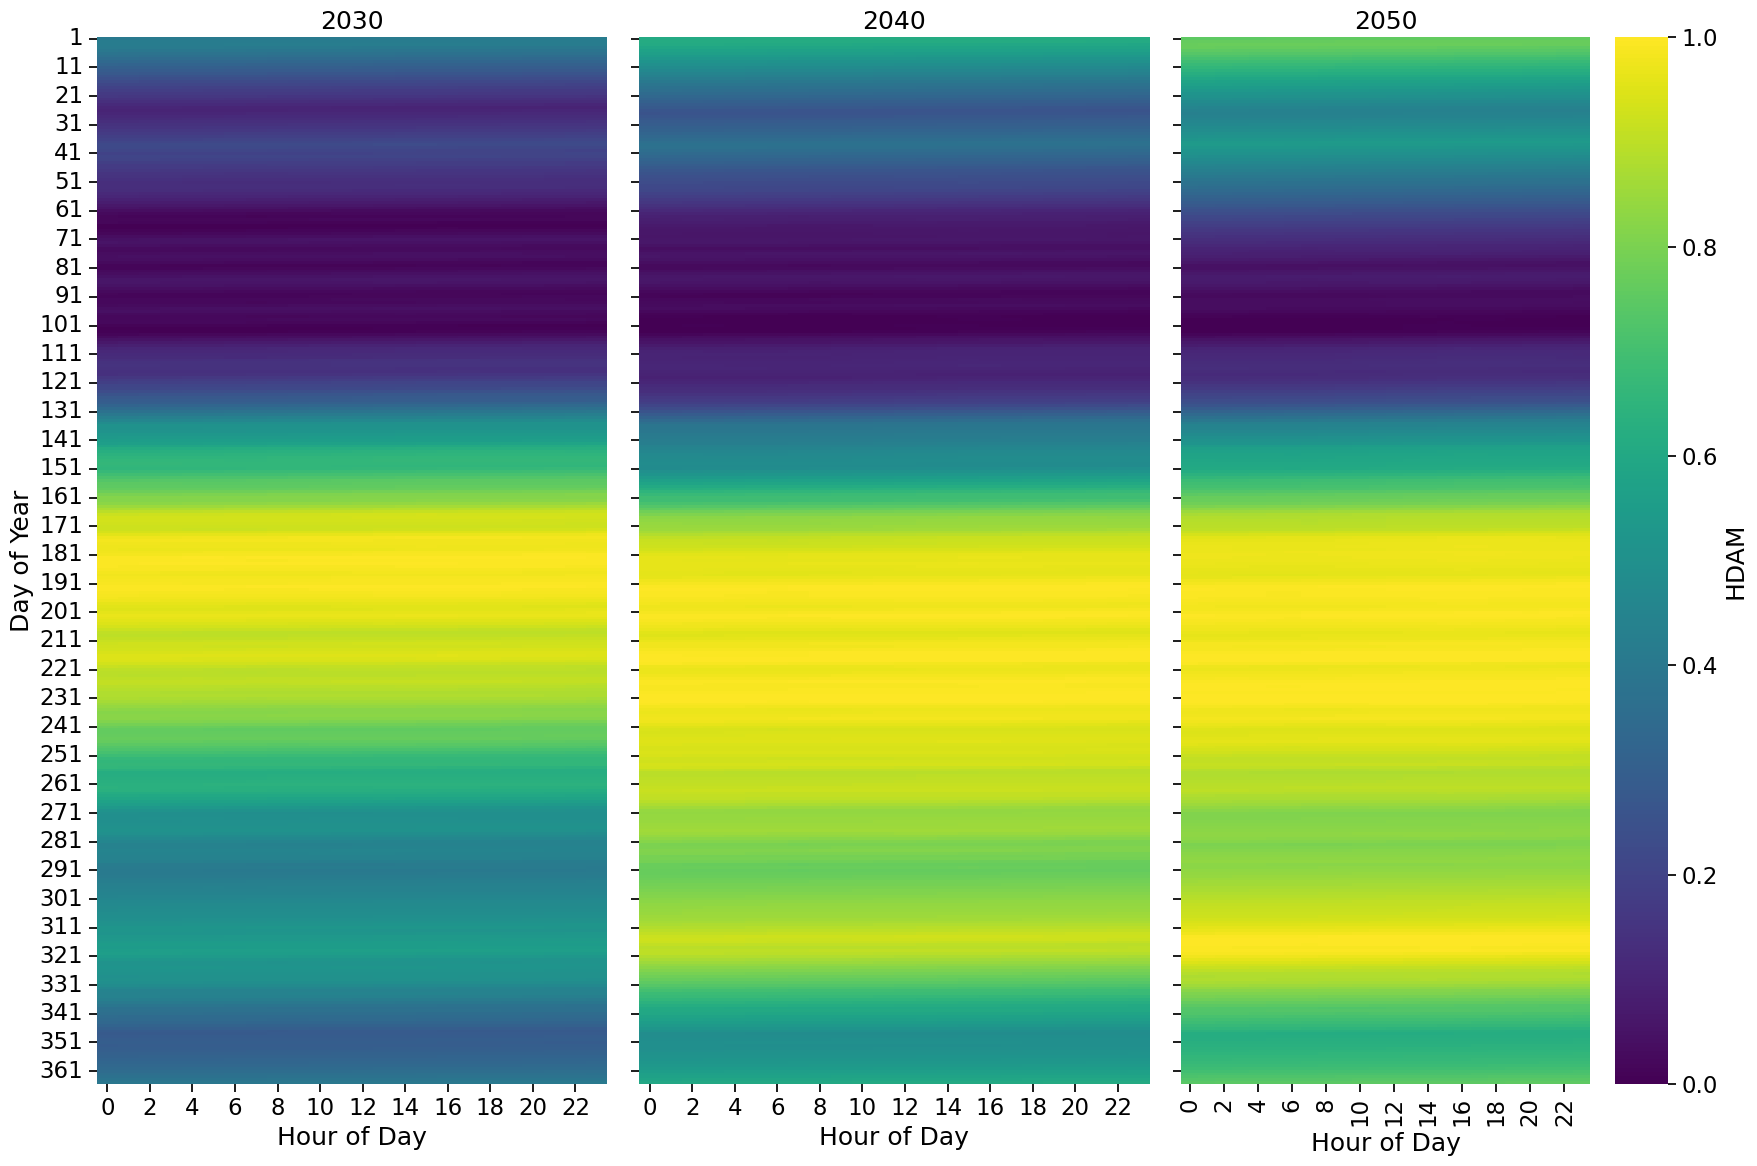

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Netherlands_HPHS_2030_2040_2050.pdf


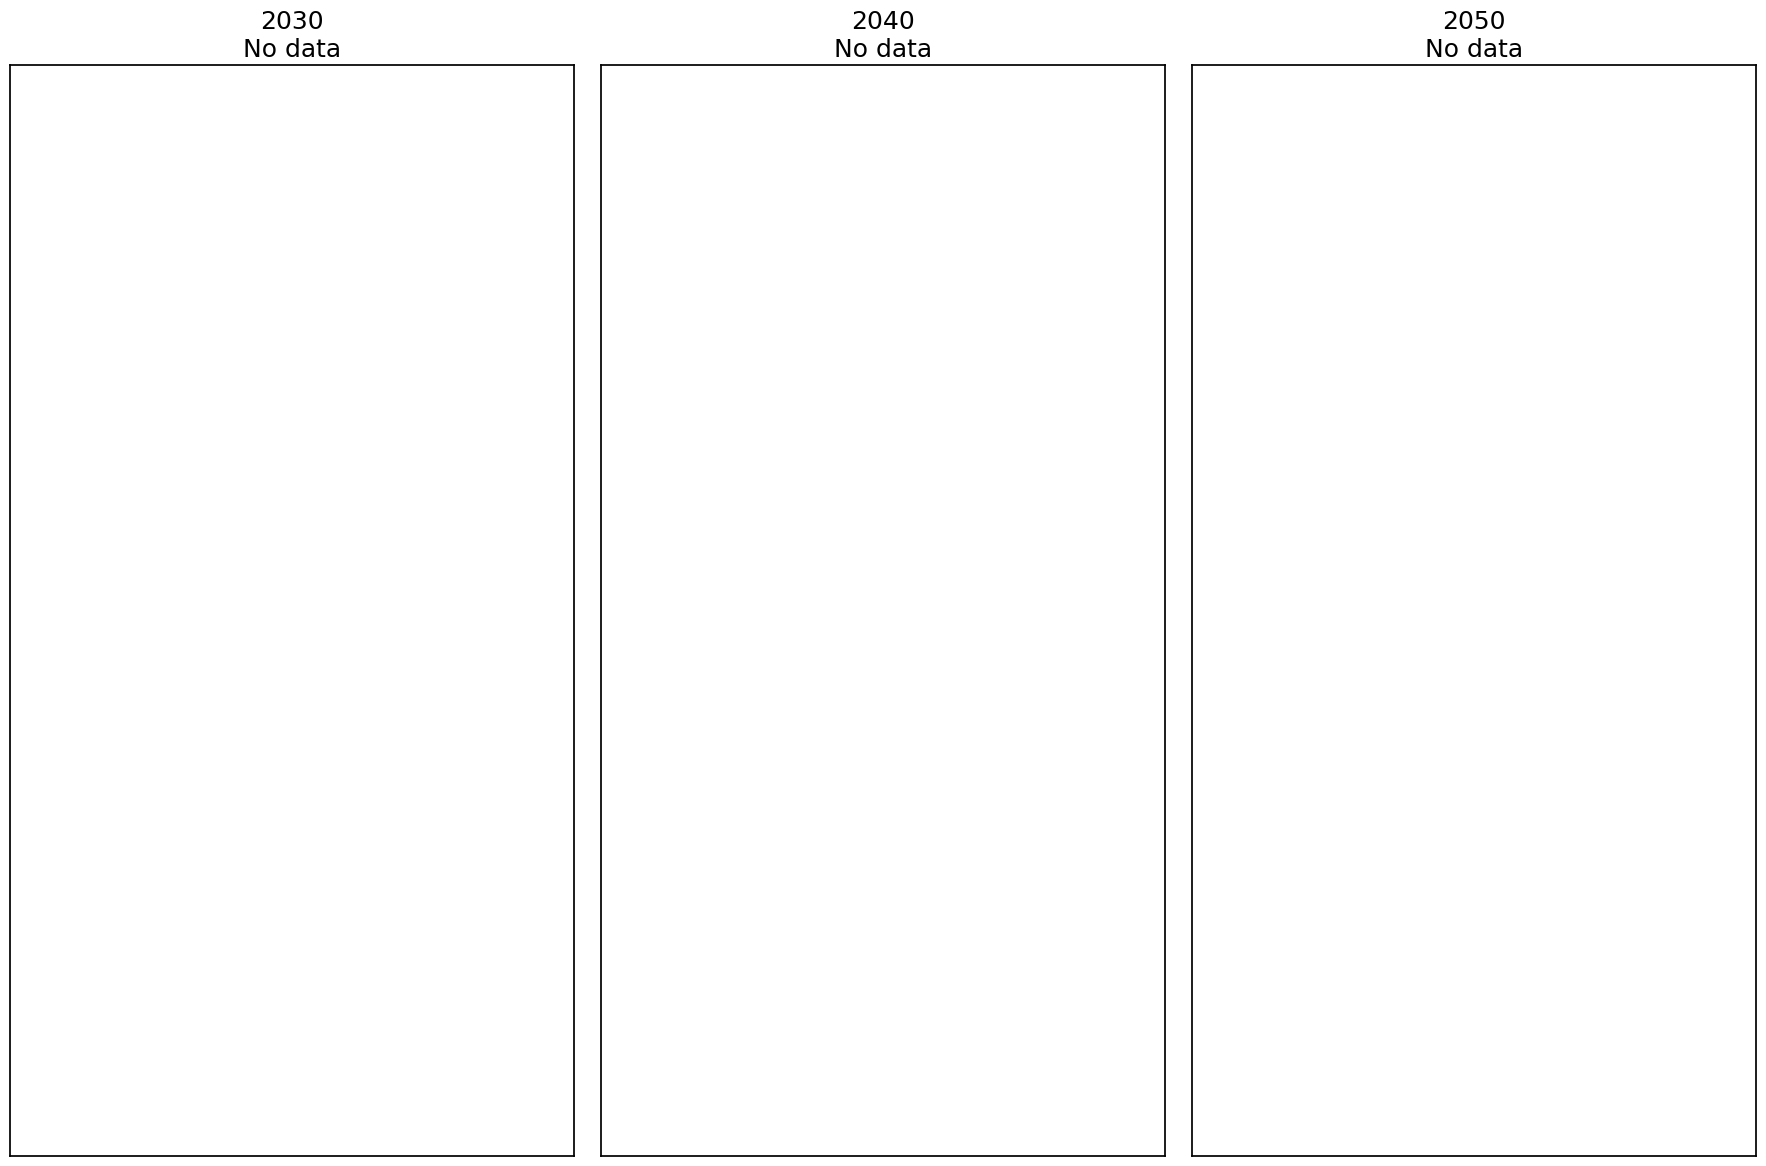

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/Netherlands_HDAM_2030_2040_2050.pdf


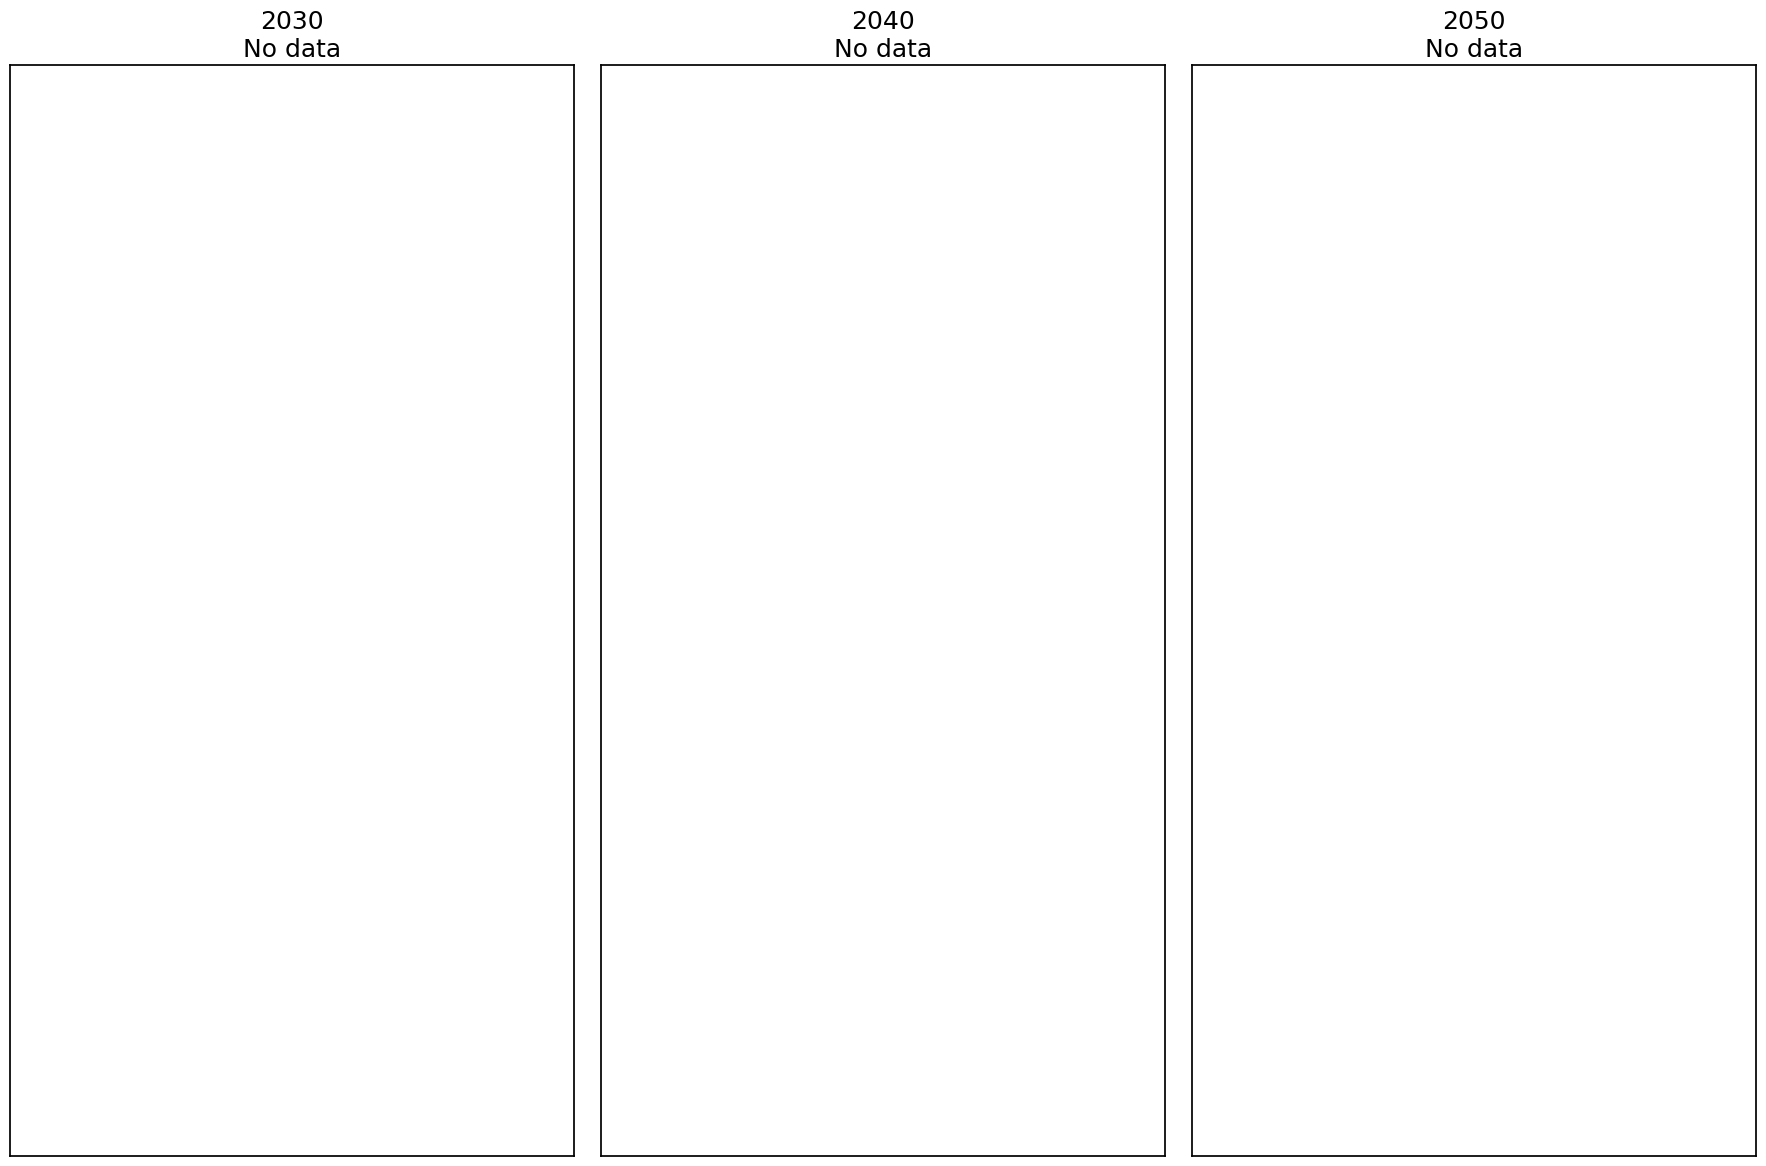

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/UK_HPHS_2030_2040_2050.pdf


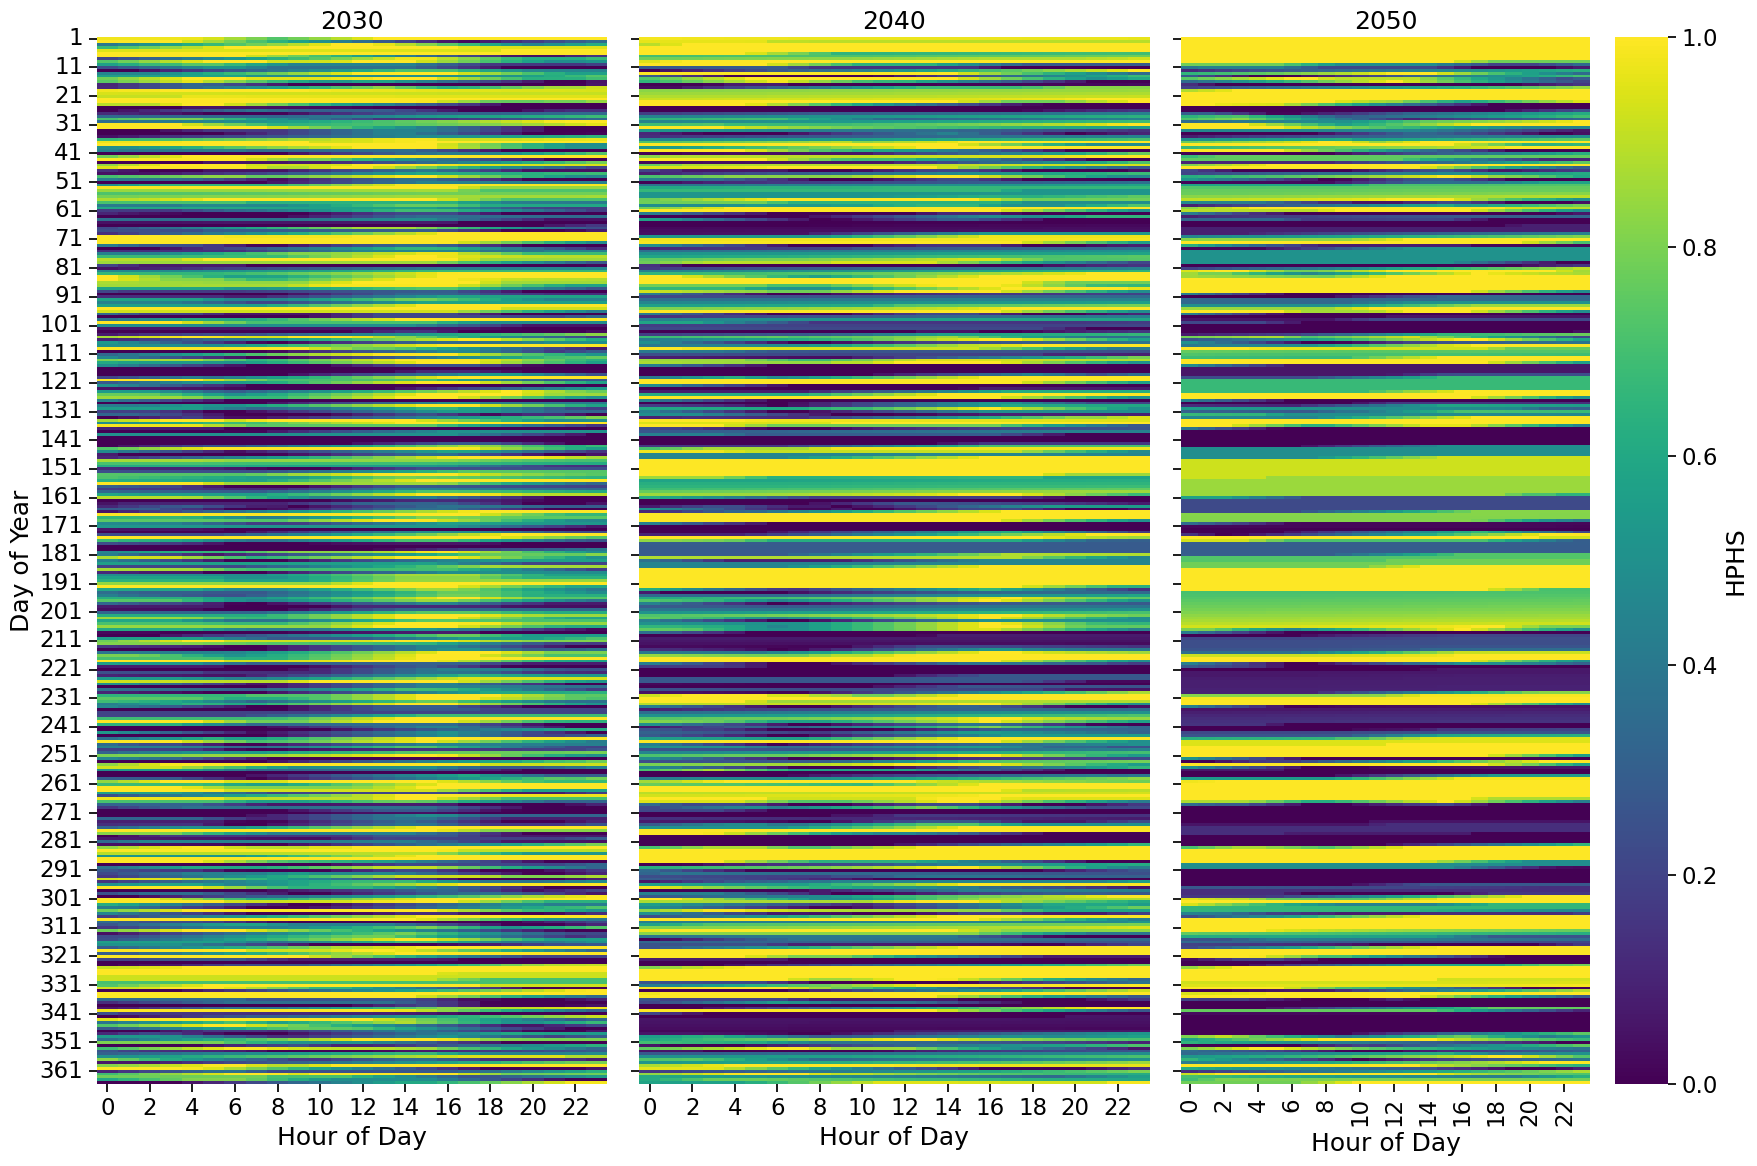

[INFO] Saved: /home/ray/Downloads/ReservoirLevelPlots/UK_HDAM_2030_2040_2050.pdf


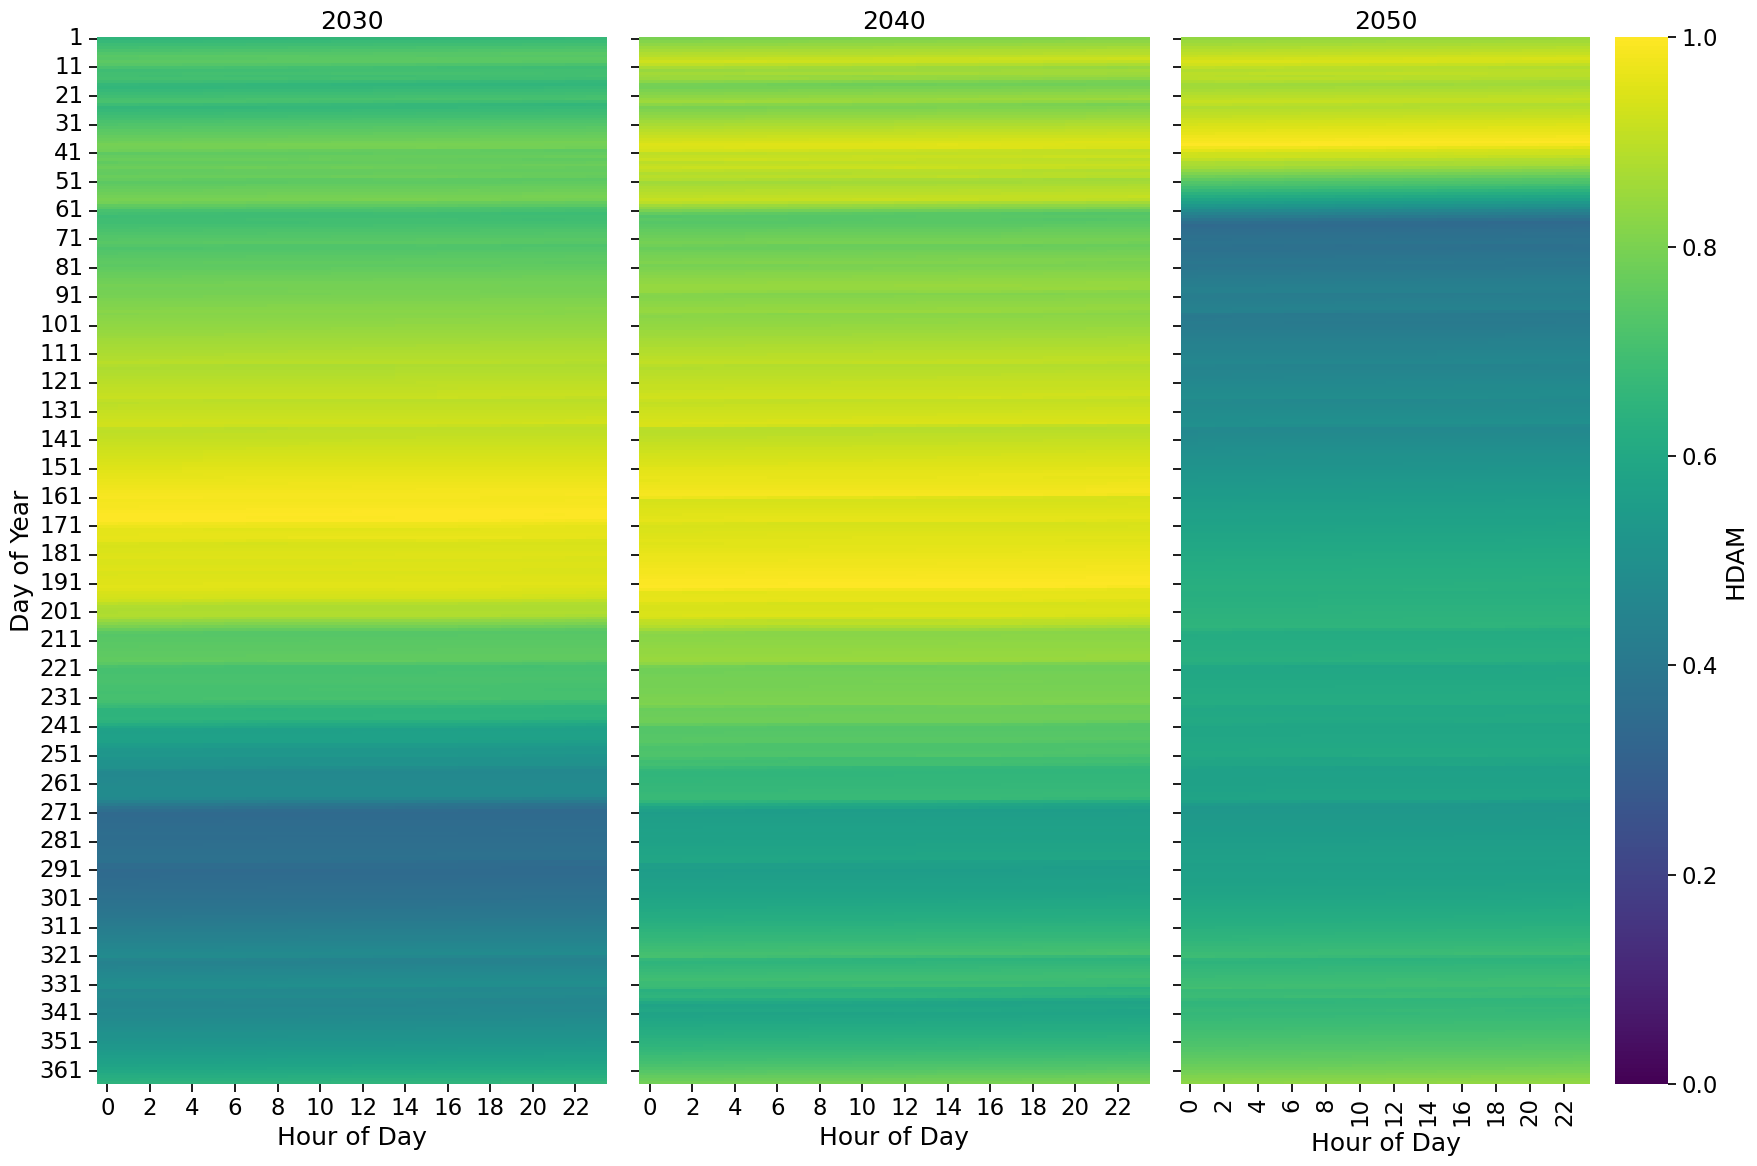

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------
# USER CONFIGURATION
# ----------------------------------
years = [2030, 2040, 2050]

variables_to_plot = [
    'HPHS',
    'HDAM'
]

countries = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/BE/1h/',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/DE/1h/',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/FR/1h/',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/NL/1h/',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/UK/1h/',
}

# -------------------------------------------------
# Main loop
# -------------------------------------------------
for country, base_path in countries.items():
    for variable in variables_to_plot:

        yearly_heatmaps = {}
        vmin, vmax = float('inf'), float('-inf')

        # -------------------------
        # Load data for each year
        # -------------------------
        for year in years:
            path = f"{base_path}{year}.csv"

            df = pd.read_csv(path, parse_dates=[0], index_col=0)

            # Safety check
            if variable not in df.columns:
                print(f"[WARNING] {variable} not found in {country} {year}")
                yearly_heatmaps[year] = None
                continue

            df['day'] = df.index.dayofyear
            df['hour'] = df.index.hour

            heatmap_data = df.pivot_table(
                values=variable,
                index='day',
                columns='hour'
            )

            if heatmap_data.empty or heatmap_data.isna().all().all():
                yearly_heatmaps[year] = None
                continue

            yearly_heatmaps[year] = heatmap_data
            vmin = min(vmin, heatmap_data.min().min())
            vmax = max(vmax, heatmap_data.max().max())

        # -------------------------
        # Plot
        # -------------------------
        fig, axes = plt.subplots(
            1, len(years),
            figsize=(18, 12),
            sharey=True
        )

#        fig.suptitle(
 #           f"{variable} – Reservoir Level – {country}",
  #          fontsize=16,
   #         y=1.05
    #    )

        for i, year in enumerate(years):
            ax = axes[i]

            if yearly_heatmaps[year] is None:
                ax.set_title(f"{year}\nNo data")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            sns.heatmap(
                yearly_heatmaps[year],
                ax=ax,
                cmap='viridis',
                vmin=0,
                vmax=1,
                cbar=i == len(years) - 1,
                cbar_kws={'label': variable}
            )

            ax.set_title(str(year))
            ax.set_xlabel("Hour of Day")
            ax.set_ylabel("Day of Year" if i == 0 else "")

        plt.tight_layout()

                # -------------------------
        # Save figure
        # -------------------------
        output_folder = '/home/ray/Downloads/ReservoirLevelPlots/'
        import os
        os.makedirs(output_folder, exist_ok=True)
        pdf_file = f"{output_folder}{country}_{variable}_2030_2040_2050.pdf"
        plt.savefig(pdf_file, bbox_inches='tight')
        print(f"[INFO] Saved: {pdf_file}")

        plt.show()



In [78]:
import pandas as pd

# --------------------------------------------------
# Countries and paths
# --------------------------------------------------
countries = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/BE/1h/',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/DE/1h/',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/FR/1h/',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/NL/1h/',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/UK/1h/',
}

years = [2030, 2040, 2050]

# Variables (columns) to analyse
variables_to_analyse = ['HPHS', 'HDAM']

# --------------------------------------------------
# Helper function to compute stats
# --------------------------------------------------
def compute_reservoir_stats(df, variable):
    """
    df: DataFrame with datetime index
    variable: column name (e.g. HPHS, HDAM)
    returns: dict with annual and quarterly averages
    """

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    # Add quarter
    df['Quarter'] = df.index.quarter

    annual_avg = df[variable].mean()

    quarterly_avg = (
        df.groupby('Quarter')[variable]
        .mean()
        .reindex([1, 2, 3, 4])
    )

    return {
        'Annual Avg': annual_avg,
        'Q1 Avg': quarterly_avg.loc[1],
        'Q2 Avg': quarterly_avg.loc[2],
        'Q3 Avg': quarterly_avg.loc[3],
        'Q4 Avg': quarterly_avg.loc[4],
    }

# --------------------------------------------------
# Build final table
# --------------------------------------------------
all_results = []

for country, base_path in countries.items():
    for year in years:
        path = f"{base_path}{year}.csv"

        df = pd.read_csv(path, index_col=0)
        df.index = pd.to_datetime(df.index, utc=True)

        for variable in variables_to_analyse:
            if variable not in df.columns:
                print(f"[WARNING] {variable} not found in {country} {year}")
                continue

            stats = compute_reservoir_stats(df, variable)

            all_results.append({
                'Country': country,
                'Year': year,
                'Variable': variable,
                'Annual Avg (%)': stats['Annual Avg'] * 100,
                'Q1 Avg (%)': stats['Q1 Avg'] * 100,
                'Q2 Avg (%)': stats['Q2 Avg'] * 100,
                'Q3 Avg (%)': stats['Q3 Avg'] * 100,
                'Q4 Avg (%)': stats['Q4 Avg'] * 100,
            })


final_table = pd.DataFrame(all_results).round(2)

print(final_table)


        Country  Year Variable  Annual Avg (%)  Q1 Avg (%)  Q2 Avg (%)  \
0       Belgium  2030     HPHS           53.88       58.02       49.35   
1       Belgium  2030     HDAM           92.85       90.89       98.01   
2       Belgium  2040     HPHS           54.70       62.20       48.86   
3       Belgium  2040     HDAM           94.59       93.88       97.57   
4       Belgium  2050     HPHS           59.28       71.89       54.89   
5       Belgium  2050     HDAM           95.52       95.93       98.19   
6       Germany  2030     HPHS           47.62       50.94       46.74   
7       Germany  2030     HDAM           33.63        9.43       35.87   
8       Germany  2040     HPHS           53.47       56.92       52.54   
9       Germany  2040     HDAM           35.39        6.65       25.38   
10      Germany  2050     HPHS           53.64       60.94       49.32   
11      Germany  2050     HDAM           35.87       16.69       30.02   
12       France  2030     HPHS        

In [77]:
import pandas as pd

countries = {
    'Belgium': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/BE/1h/',
    'Germany': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/DE/1h/',
    'France': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/FR/1h/',
    'Netherlands': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/NL/1h/',
    'UK': '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/HydroData/ReservoirLevel/UK/1h/',
}

years = [2030, 2040, 2050]
variables = ['HPHS', 'HDAM']

def compute_quarterly_stats(df, variable):
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)

    df['Quarter'] = df.index.quarter

    return {
        'Annual Avg': df[variable].mean(),
        'Q1 Avg': df[df['Quarter'] == 1][variable].mean(),
        'Q2 Avg': df[df['Quarter'] == 2][variable].mean(),
        'Q3 Avg': df[df['Quarter'] == 3][variable].mean(),
        'Q4 Avg': df[df['Quarter'] == 4][variable].mean(),
    }

final_results = []

for country, base_path in countries.items():
    for variable in variables:

        yearly_stats = []

        for year in years:
            path = f"{base_path}{year}.csv"

            df = pd.read_csv(path, index_col=0)
            df.index = pd.to_datetime(df.index, utc=True)

            if variable not in df.columns:
                print(f"[WARNING] {variable} missing in {country} {year}")
                continue

            stats = compute_quarterly_stats(df, variable)
            yearly_stats.append(stats)

        # Skip if no data
        if not yearly_stats:
            continue

        # Convert to DataFrame and average over years
        stats_df = pd.DataFrame(yearly_stats)
        mean_stats = stats_df.mean()

        final_results.append({
            'Country': country,
            'Variable': variable,
            'Annual Avg (%)': mean_stats['Annual Avg'] * 100,
            'Q1 Avg (%)': mean_stats['Q1 Avg'] * 100,
            'Q2 Avg (%)': mean_stats['Q2 Avg'] * 100,
            'Q3 Avg (%)': mean_stats['Q3 Avg'] * 100,
            'Q4 Avg (%)': mean_stats['Q4 Avg'] * 100,
        })

final_table = pd.DataFrame(final_results).round(2)
print(final_table)


       Country Variable  Annual Avg (%)  Q1 Avg (%)  Q2 Avg (%)  Q3 Avg (%)  \
0      Belgium     HPHS           55.95       64.04       51.03       49.56   
1      Belgium     HDAM           94.32       93.57       97.92       95.82   
2      Germany     HPHS           51.58       56.27       49.53       50.42   
3      Germany     HDAM           34.96       10.92       30.42       76.40   
4       France     HPHS           52.38       59.25       46.26       51.40   
5       France     HDAM           56.63       25.31       43.48       90.99   
6  Netherlands     HPHS             NaN         NaN         NaN         NaN   
7  Netherlands     HDAM             NaN         NaN         NaN         NaN   
8           UK     HPHS           52.34       58.37       48.57       51.51   
9           UK     HDAM           70.05       75.92       77.56       69.29   

   Q4 Avg (%)  
0       59.28  
1       89.98  
2       50.15  
3       21.63  
4       52.65  
5       66.09  
6         NaN  
7 